# Topic 4: Neural Networks


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint, solve_ivp
from scipy.signal import find_peaks
from numba import njit, prange

# Plot configuration
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

---
## Exercise 1: Logic gates with McCulloch-Pitts neurons

### Physical model

The **McCulloch-Pitts (1943)** model is the first mathematical model of an artificial neuron. Each formal neuron is a logic gate with two possible states:
- $s_i = 1$ (active / firing)
- $s_i = 0$ (silent / at rest)

The post-synaptic neuron receives inputs from $N$ pre-synaptic neurons, which are weighted and summed into the **local field**:

$$h_i = \sum_{j=1}^{N} w_{ij} s_j$$

where $w_{ij}$ are the **synaptic weights** (positive or negative).

The neuron's state is determined by comparing the local field with a **threshold** $\theta_i$:

$$s_i = \Theta(h_i - \theta_i) = \begin{cases} 1 & \text{if } h_i > \theta_i \\ 0 & \text{if } h_i \leq \theta_i \end{cases}$$

### Goal
Implement the logic gates **NOT, AND, OR, XOR** by choosing appropriate weights $w_{ij}$ and thresholds $\theta_i$.


In [4]:
def mcculloch_pitts(inputs, weights, threshold):
    """
    Neurona de McCulloch-Pitts.
    
    Parámetros:
    -----------
    inputs : array-like
        Estados de las neuronas presinápticas (0 o 1)
    weights : array-like
        Pesos sinápticos w_ij
    threshold : float
        Umbral de disparo θ
    
    Retorna:
    --------
    int : Estado de la neurona (0 o 1)
    """
    h = np.dot(weights, inputs)  # Campo local
    return 1 if h > threshold else 0

def test_gate(gate_name, weights, threshold, n_inputs=2):
    """
    Prueba una puerta lógica para todas las combinaciones de entrada.
    """
    print(f"\n{'='*40}")
    print(f"Puerta {gate_name}")
    print(f"Pesos: {weights}, Umbral: {threshold}")
    print(f"{'='*40}")
    
    if n_inputs == 1:
        inputs_list = [[0], [1]]
        print(f"{'A':^5} | {'Salida':^6}")
    else:
        inputs_list = [[0,0], [0,1], [1,0], [1,1]]
        print(f"{'A':^5} | {'B':^5} | {'Salida':^6}")
    print("-" * 25)
    
    outputs = []
    for inp in inputs_list:
        out = mcculloch_pitts(inp, weights, threshold)
        outputs.append(out)
        if n_inputs == 1:
            print(f"{inp[0]:^5} | {out:^6}")
        else:
            print(f"{inp[0]:^5} | {inp[1]:^5} | {out:^6}")
    
    return outputs

# ============================================
# NOT GATE: s = NOT(A)
# ============================================
# Truth table: A=0 -> 1, A=1 -> 0
# h = w*A, queremos: h > θ cuando A=0, h ≤ θ cuando A=1
# Solución: w = -1, θ = -0.5
# A=0: h = 0 > -0.5 ✓ -> 1
# A=1: h = -1 ≤ -0.5 ✓ -> 0

w_not = [-1]
theta_not = -0.5
test_gate("NOT", w_not, theta_not, n_inputs=1)

# ============================================
# AND GATE: s = A AND B
# ============================================
# Truth table: solo 1 cuando A=1 Y B=1
# h = w1*A + w2*B
# Solución: w1 = w2 = 1, θ = 1.5
# (0,0): h=0, (0,1): h=1, (1,0): h=1, (1,1): h=2
# Solo h=2 > 1.5

w_and = [1, 1]
theta_and = 1.5
test_gate("AND", w_and, theta_and)

# ============================================
# OR GATE: s = A OR B
# ============================================
# Truth table: 1 cuando A=1 O B=1 (o ambos)
# Solución: w1 = w2 = 1, θ = 0.5
# (0,0): h=0 ≤ 0.5 -> 0
# (0,1), (1,0): h=1 > 0.5 -> 1
# (1,1): h=2 > 0.5 -> 1

w_or = [1, 1]
theta_or = 0.5
test_gate("OR", w_or, theta_or)

# ============================================
# XOR GATE: s = A XOR B
# ============================================
# Truth table: 1 cuando A≠B
# XOR NO es linealmente separable -> necesita 2 capas
# XOR = (A OR B) AND NOT(A AND B)
# Capa 1: neurona OR y neurona NAND
# Capa 2: neurona AND que combina las salidas

print(f"\n{'='*40}")
print("Puerta XOR (requiere 2 capas)")
print("XOR = (A OR B) AND NOT(A AND B)")
print(f"{'='*40}")

def xor_network(A, B):
    """
    Red de 2 capas para implementar XOR.
    Capa 1: OR y NAND en paralelo
    Capa 2: AND de las salidas
    """
    # Capa 1
    or_out = mcculloch_pitts([A, B], [1, 1], 0.5)      # A OR B
    nand_out = mcculloch_pitts([A, B], [-1, -1], -1.5)  # NOT(A AND B)
    
    # Capa 2
    xor_out = mcculloch_pitts([or_out, nand_out], [1, 1], 1.5)  # AND
    
    return xor_out, or_out, nand_out

print(f"{'A':^5} | {'B':^5} | {'OR':^5} | {'NAND':^5} | {'XOR':^6}")
print("-" * 40)
for A, B in [(0,0), (0,1), (1,0), (1,1)]:
    xor_out, or_out, nand_out = xor_network(A, B)
    print(f"{A:^5} | {B:^5} | {or_out:^5} | {nand_out:^5} | {xor_out:^6}")


Puerta NOT
Pesos: [-1], Umbral: -0.5
  A   | Salida
-------------------------
  0   |   1   
  1   |   0   

Puerta AND
Pesos: [1, 1], Umbral: 1.5
  A   |   B   | Salida
-------------------------
  0   |   0   |   0   
  0   |   1   |   0   
  1   |   0   |   0   
  1   |   1   |   1   

Puerta OR
Pesos: [1, 1], Umbral: 0.5
  A   |   B   | Salida
-------------------------
  0   |   0   |   0   
  0   |   1   |   1   
  1   |   0   |   1   
  1   |   1   |   1   

Puerta XOR (requiere 2 capas)
XOR = (A OR B) AND NOT(A AND B)
  A   |   B   |  OR   | NAND  |  XOR  
----------------------------------------
  0   |   0   |   0   |   1   |   0   
  0   |   1   |   1   |   1   |   1   
  1   |   0   |   1   |   1   |   1   
  1   |   1   |   1   |   0   |   0   


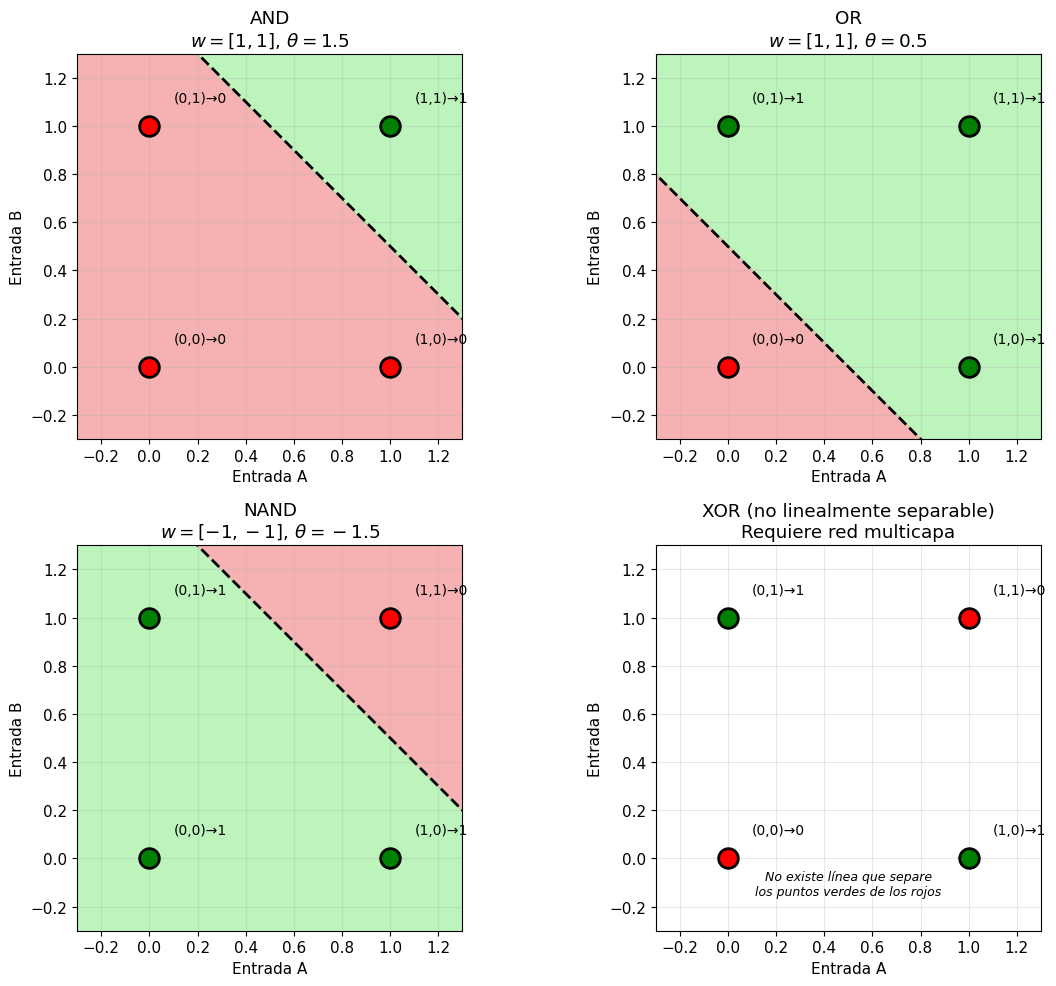


Figura 1: Regiones de decisión para puertas lógicas McCulloch-Pitts.
La línea discontinua representa el umbral h = θ. Verde = salida 1, Rojo = salida 0.
XOR no es linealmente separable y requiere una red de 2 capas.


In [5]:
# Visualization / Plot de las regiones de decisión
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

def plot_decision_region(ax, weights, threshold, title, gate_outputs):
    """Visualiza la región de decisión de una puerta lógica."""
    # Create malla
    x = np.linspace(-0.5, 1.5, 100)
    y = np.linspace(-0.5, 1.5, 100)
    X, Y = np.meshgrid(x, y)
    
    # Calculate campo local
    H = weights[0]*X + weights[1]*Y
    
    # Decision region
    Z = (H > threshold).astype(int)
    
    # Plot
    ax.contourf(X, Y, Z, levels=[-0.5, 0.5, 1.5], colors=['lightcoral', 'lightgreen'], alpha=0.6)
    ax.contour(X, Y, H, levels=[threshold], colors='black', linewidths=2, linestyles='--')
    
    # Puntos de entrada
    inputs = [(0,0), (0,1), (1,0), (1,1)]
    for i, (a, b) in enumerate(inputs):
        color = 'green' if gate_outputs[i] == 1 else 'red'
        ax.scatter(a, b, s=200, c=color, edgecolors='black', linewidths=2, zorder=5)
        ax.annotate(f'({a},{b})→{gate_outputs[i]}', (a+0.1, b+0.1), fontsize=10)
    
    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(-0.3, 1.3)
    ax.set_xlabel('Entrada A')
    ax.set_ylabel('Entrada B')
    ax.set_title(f'{title}\n$w = {weights}$, $\\theta = {threshold}$')
    ax.set_aspect('equal')

# AND
plot_decision_region(axes[0,0], [1,1], 1.5, 'AND', [0,0,0,1])

# OR
plot_decision_region(axes[0,1], [1,1], 0.5, 'OR', [0,1,1,1])

# NAND (para XOR)
plot_decision_region(axes[1,0], [-1,-1], -1.5, 'NAND', [1,1,1,0])

# XOR (no linealmente separable)
ax = axes[1,1]
ax.set_xlim(-0.3, 1.3)
ax.set_ylim(-0.3, 1.3)
xor_outputs = [0, 1, 1, 0]
inputs = [(0,0), (0,1), (1,0), (1,1)]
for i, (a, b) in enumerate(inputs):
    color = 'green' if xor_outputs[i] == 1 else 'red'
    ax.scatter(a, b, s=200, c=color, edgecolors='black', linewidths=2, zorder=5)
    ax.annotate(f'({a},{b})→{xor_outputs[i]}', (a+0.1, b+0.1), fontsize=10)
ax.set_xlabel('Entrada A')
ax.set_ylabel('Entrada B')
ax.set_title('XOR (no linealmente separable)\nRequiere red multicapa')
ax.set_aspect('equal')
ax.text(0.5, -0.15, 'No existe línea que separe\nlos puntos verdes de los rojos', 
        ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

print("\nFigura 1: Regiones de decisión para puertas lógicas McCulloch-Pitts.")
print("La línea discontinua representa el umbral h = θ. Verde = salida 1, Rojo = salida 0.")
print("XOR no es linealmente separable y requiere una red de 2 capas.")

### Discussion — Exercise 1

**Results:**

| Gate | Weights $w$ | Threshold $\theta$ | Layers |
|------|-------------|---------------------|--------|
| NOT  | $[-1]$      | $-0.5$              | 1      |
| AND  | $[1, 1]$    | $1.5$               | 1      |
| OR   | $[1, 1]$    | $0.5$               | 1      |
| XOR  | Multi-layer | —                   | 2      |

**Observations:**

1. Gates **NOT, AND and OR** are **linearly separable**: a hyperplane (line in 2D) separates inputs that produce output 1 from those that produce output 0.

2. **XOR is not linearly separable**. This is the classic **XOR problem**, one of the main criticisms of single-layer perceptrons (Minsky & Papert, 1969). It is solved with a two-layer network.

3. The choice of weights and thresholds is not unique. For AND, $w = [2, 2]$, $\theta = 3$ also works.

4. This model is the foundation of **modern artificial neural networks**, though those use continuous activation functions (sigmoid, ReLU) instead of the Heaviside step.


---
## Exercise 2: Hodgkin-Huxley model simulation

### Physical model

The **Hodgkin-Huxley (1952)** model describes the generation and propagation of action potentials in the squid giant axon. It is a biophysical model based on the equivalent electrical circuit of the cell membrane.

**Main equation** (charge conservation):
$$C_m \frac{dV}{dt} = -F(V, m, h, n) + I$$

where $C_m = 1\,\mu\text{F/cm}^2$ is the membrane capacitance, $V$ is the membrane potential, $I$ is the injected current, and $F$ represents the ionic currents:

$$F(V, m, h, n) = g_L(V - V_L) + g_K n^4 (V - V_K) + g_{\rm Na} m^3 h (V - V_{\rm Na})$$

**Gating variables** ($m$, $h$, $n$):
- $m$: Na⁺ channel activation (fast)
- $h$: Na⁺ channel inactivation (slow)
- $n$: K⁺ channel activation (slow)

Each variable follows:
$$\tau_x(V) \frac{dx}{dt} = x_\infty(V) - x \quad \text{for } x \in \{m, h, n\}$$

### Goal
Simulate the HH model, reproduce the action potential, analyse gating functions, and compute the firing-frequency bifurcation diagram.


In [13]:
class HodgkinHuxley:
    """
    Modelo de Hodgkin-Huxley del axón gigante del calamar.
    
    Parámetros:
    -----------
    Cm : float
        Capacitancia de membrana (μF/cm²)
    gL, gK, gNa : float
        Conductancias máximas (mS/cm²)
    VL, VK, VNa : float
        Potenciales de inversión (mV)
    """
    
    def __init__(self):
        # Parameters estándar
        self.Cm = 1.0      # μF/cm²
        self.gL = 0.3      # mS/cm²
        self.gK = 36.0     # mS/cm²
        self.gNa = 120.0   # mS/cm²
        self.VL = -54.402  # mV
        self.VK = -77.0    # mV
        self.VNa = 50.0    # mV
    
    # Funciones de tasa α y β para cada variable de compuerta
    # (versiones numéricamente estables)
    
    def alpha_m(self, V):
        x = V + 40
        if abs(x) < 1e-6:
            return 1.0  # Límite por L'Hôpital
        exp_term = np.exp(np.clip(-0.1 * x, -700, 700))
        return 0.1 * x / (1 - exp_term)
    
    def beta_m(self, V):
        return 4.0 * np.exp(np.clip(-0.0556 * (V + 65), -700, 700))
    
    def alpha_h(self, V):
        return 0.07 * np.exp(np.clip(-0.05 * (V + 65), -700, 700))
    
    def beta_h(self, V):
        return 1.0 / (1 + np.exp(np.clip(-0.1 * (V + 35), -700, 700)))
    
    def alpha_n(self, V):
        x = V + 55
        if abs(x) < 1e-6:
            return 0.1  # Límite por L'Hôpital
        exp_term = np.exp(np.clip(-0.1 * x, -700, 700))
        return 0.01 * x / (1 - exp_term)
    
    def beta_n(self, V):
        return 0.125 * np.exp(np.clip(-0.0125 * (V + 65), -700, 700))
    
    # Valores estacionarios y constantes de tiempo
    # Valores estacionarios y constantes de tiempo
    def x_inf(self, alpha, beta):
        denom = alpha + beta
        if denom < 1e-10:
            return 0.5
        return alpha / denom
    
    def tau_x(self, alpha, beta):
        denom = alpha + beta
        if denom < 1e-10:
            return 1e10  # Valor grande pero finito
        return 1.0 / denom
    
    def m_inf(self, V):
        return self.x_inf(self.alpha_m(V), self.beta_m(V))
    
    def h_inf(self, V):
        return self.x_inf(self.alpha_h(V), self.beta_h(V))
    
    def n_inf(self, V):
        return self.x_inf(self.alpha_n(V), self.beta_n(V))
    
    def tau_m(self, V):
        return self.tau_x(self.alpha_m(V), self.beta_m(V))
    
    def tau_h(self, V):
        return self.tau_x(self.alpha_h(V), self.beta_h(V))
    
    def tau_n(self, V):
        return self.tau_x(self.alpha_n(V), self.beta_n(V))
    
    def F(self, V, m, h, n):
        """Corrientes iónicas totales."""
        IL = self.gL * (V - self.VL)
        IK = self.gK * n**4 * (V - self.VK)
        INa = self.gNa * m**3 * h * (V - self.VNa)
        return IL + IK + INa
    
    def derivatives(self, t, y, I_ext):
        """
        Sistema de EDOs del modelo HH.
        y = [V, m, h, n]
        """
        V, m, h, n = y
        
        # Limitar V a un rango razonable para evitar overflow
        V = np.clip(V, -150, 150)
        
        # Limitar variables de compuerta a [0, 1]
        m = np.clip(m, 0, 1)
        h = np.clip(h, 0, 1)
        n = np.clip(n, 0, 1)
        
        # Corriente externa (puede ser función del tiempo)
        if callable(I_ext):
            I = I_ext(t)
        else:
            I = I_ext
        
        # Derivadas
        dVdt = (-self.F(V, m, h, n) + I) / self.Cm
        
        tau_m = max(self.tau_m(V), 1e-6)
        tau_h = max(self.tau_h(V), 1e-6)
        tau_n = max(self.tau_n(V), 1e-6)
        
        dmdt = (self.m_inf(V) - m) / tau_m
        dhdt = (self.h_inf(V) - h) / tau_h
        dndt = (self.n_inf(V) - n) / tau_n
        
        return [dVdt, dmdt, dhdt, dndt]
    
    def simulate(self, I_ext, T=100, dt=0.01, V0=-65):
        """
        Simula el modelo HH.
        
        Parámetros:
        -----------
        I_ext : float o callable
            Corriente externa (μA/cm²)
        T : float
            Tiempo total de simulación (ms)
        dt : float
            Paso temporal (ms)
        V0 : float
            Potencial inicial (mV)
        
        Retorna:
        --------
        t, V, m, h, n : arrays
        """
        # Condiciones iniciales en equilibrio
        m0 = self.m_inf(V0)
        h0 = self.h_inf(V0)
        n0 = self.n_inf(V0)
        y0 = [V0, m0, h0, n0]
        
        # Integración
        t_span = (0, T)
        t_eval = np.arange(0, T, dt)
        
        sol = solve_ivp(self.derivatives, t_span, y0, 
                        args=(I_ext,), t_eval=t_eval, method='RK45')
        
        return sol.t, sol.y[0], sol.y[1], sol.y[2], sol.y[3]

# Create instancia del modelo
hh = HodgkinHuxley()

print("Modelo de Hodgkin-Huxley inicializado.")
print(f"Parámetros: gL={hh.gL}, gK={hh.gK}, gNa={hh.gNa} mS/cm²")

Modelo de Hodgkin-Huxley inicializado.
Parámetros: gL=0.3, gK=36.0, gNa=120.0 mS/cm²


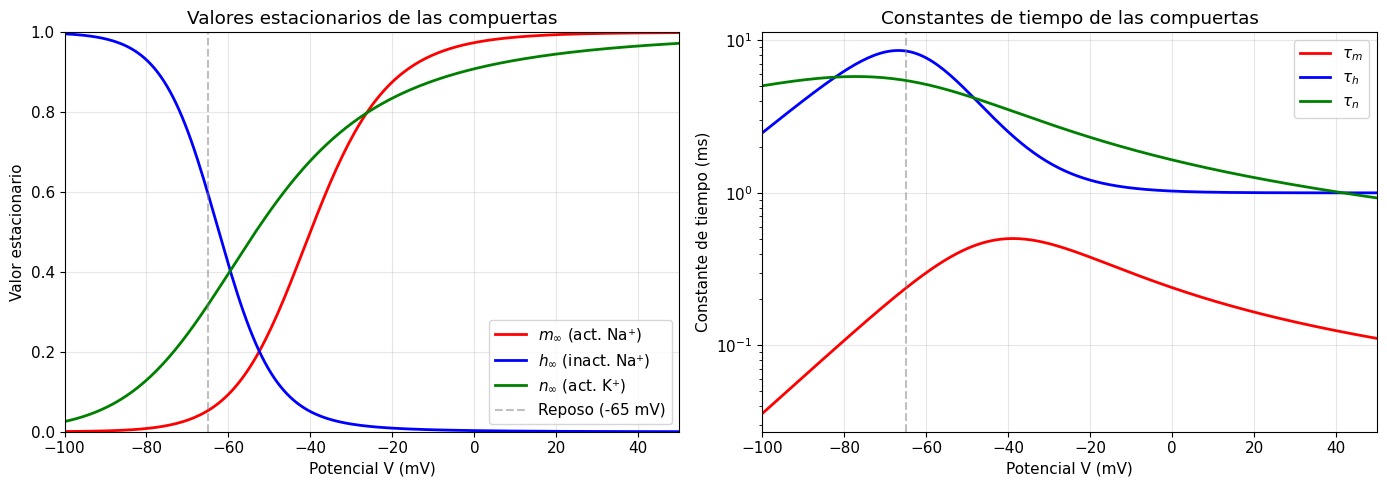


Figura 2: Propiedades de las variables de compuerta en el modelo de Hodgkin-Huxley.
Izquierda: Valores estacionarios m∞, h∞, n∞ vs V.
Derecha: Constantes de tiempo τm ≪ τh, τn (m es mucho más rápida).


In [14]:
# Visualize las funciones de compuerta
V_range = np.linspace(-100, 50, 200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: valores estacionarios
ax1 = axes[0]
ax1.plot(V_range, [hh.m_inf(V) for V in V_range], 'r-', lw=2, label=r'$m_\infty$ (act. Na⁺)')
ax1.plot(V_range, [hh.h_inf(V) for V in V_range], 'b-', lw=2, label=r'$h_\infty$ (inact. Na⁺)')
ax1.plot(V_range, [hh.n_inf(V) for V in V_range], 'g-', lw=2, label=r'$n_\infty$ (act. K⁺)')
ax1.axvline(-65, color='gray', linestyle='--', alpha=0.5, label='Reposo (-65 mV)')
ax1.set_xlabel('Potencial V (mV)')
ax1.set_ylabel('Valor estacionario')
ax1.set_title('Valores estacionarios de las compuertas')
ax1.legend()
ax1.set_xlim(-100, 50)
ax1.set_ylim(0, 1)

# Panel derecho: constantes de tiempo
ax2 = axes[1]
ax2.plot(V_range, [hh.tau_m(V) for V in V_range], 'r-', lw=2, label=r'$\tau_m$')
ax2.plot(V_range, [hh.tau_h(V) for V in V_range], 'b-', lw=2, label=r'$\tau_h$')
ax2.plot(V_range, [hh.tau_n(V) for V in V_range], 'g-', lw=2, label=r'$\tau_n$')
ax2.axvline(-65, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('Potencial V (mV)')
ax2.set_ylabel('Constante de tiempo (ms)')
ax2.set_title('Constantes de tiempo de las compuertas')
ax2.legend()
ax2.set_xlim(-100, 50)
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

print("\nFigura 2: Propiedades de las variables de compuerta en el modelo de Hodgkin-Huxley.")
print("Izquierda: Valores estacionarios m∞, h∞, n∞ vs V.")
print("Derecha: Constantes de tiempo τm ≪ τh, τn (m es mucho más rápida).")

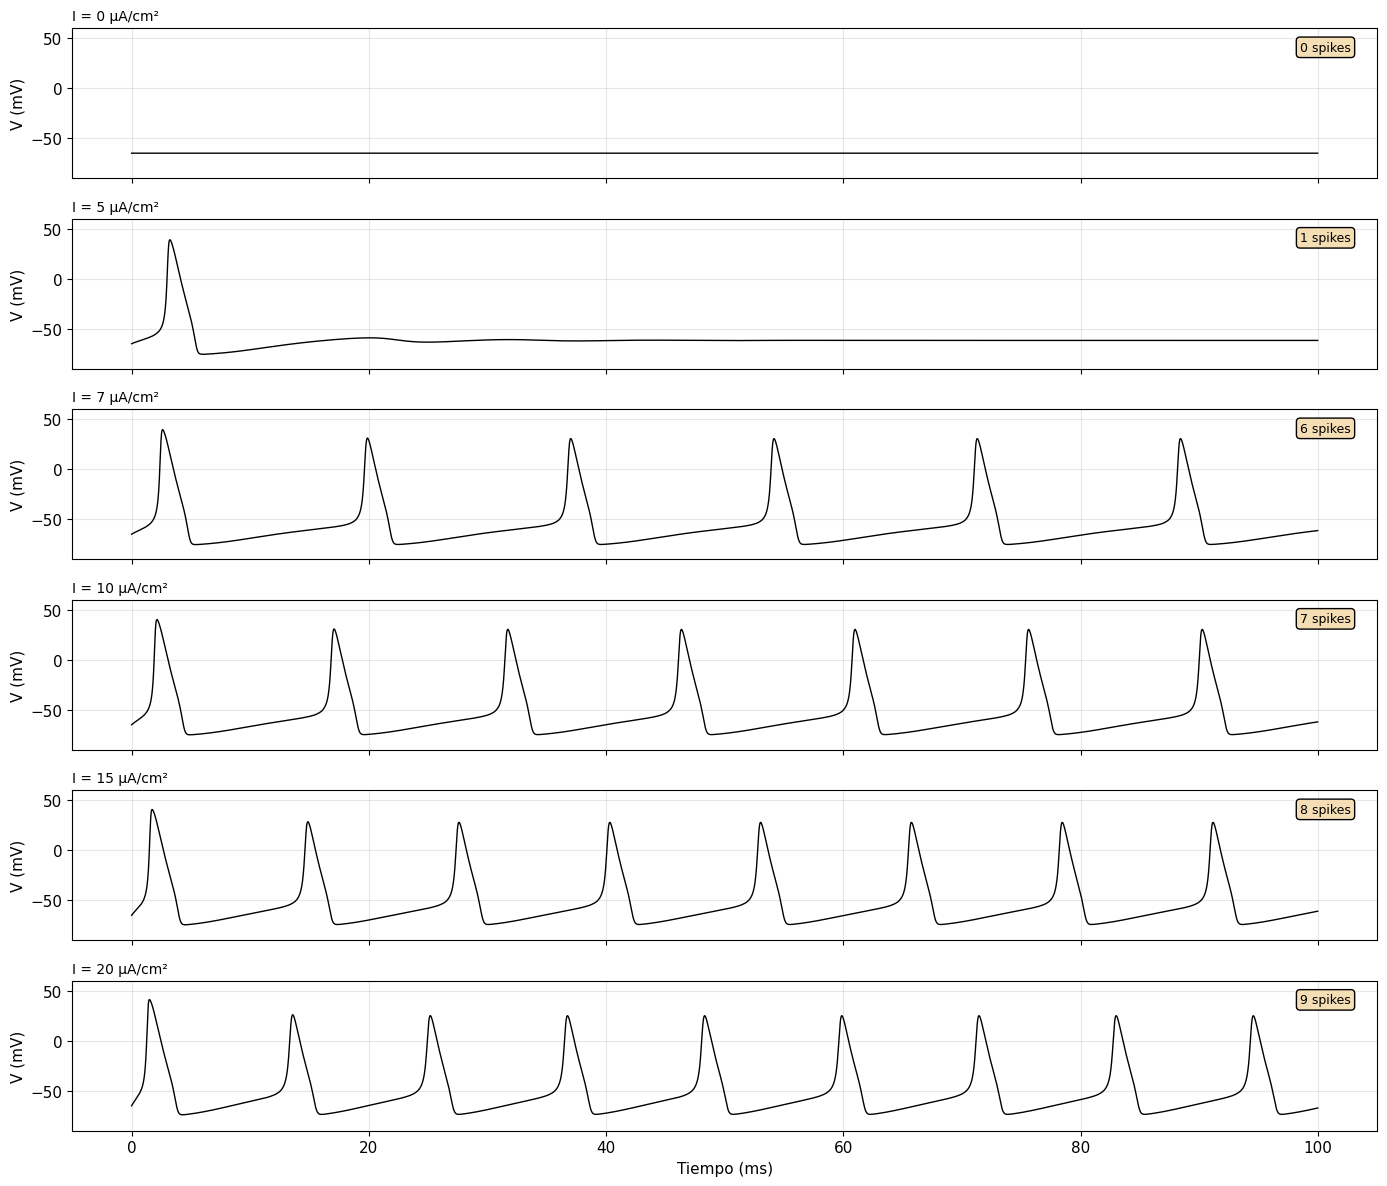


Figura 3: Respuesta del modelo HH a diferentes corrientes inyectadas.
Modelo: Hodgkin-Huxley estándar. T = 100 ms, V₀ = -65 mV.


In [15]:
# Simulation para diferentes valores de corriente
I_values = [0, 5, 7, 10, 15, 20]
T = 100  # ms

fig, axes = plt.subplots(len(I_values), 1, figsize=(14, 12), sharex=True)

for i, I in enumerate(I_values):
    t, V, m, h, n = hh.simulate(I, T=T)
    
    axes[i].plot(t, V, 'k-', lw=1)
    axes[i].set_ylabel('V (mV)')
    axes[i].set_title(f'I = {I} μA/cm²', loc='left', fontsize=10)
    axes[i].set_ylim(-90, 60)
    
    # Contar spikes
    peaks, _ = find_peaks(V, height=0)
    n_spikes = len(peaks)
    axes[i].text(0.98, 0.85, f'{n_spikes} spikes', transform=axes[i].transAxes, 
                 ha='right', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat'))

axes[-1].set_xlabel('Tiempo (ms)')
plt.tight_layout()
plt.show()

print("\nFigura 3: Respuesta del modelo HH a diferentes corrientes inyectadas.")
print(f"Modelo: Hodgkin-Huxley estándar. T = {T} ms, V₀ = -65 mV.")

Calculando diagrama de bifurcación...


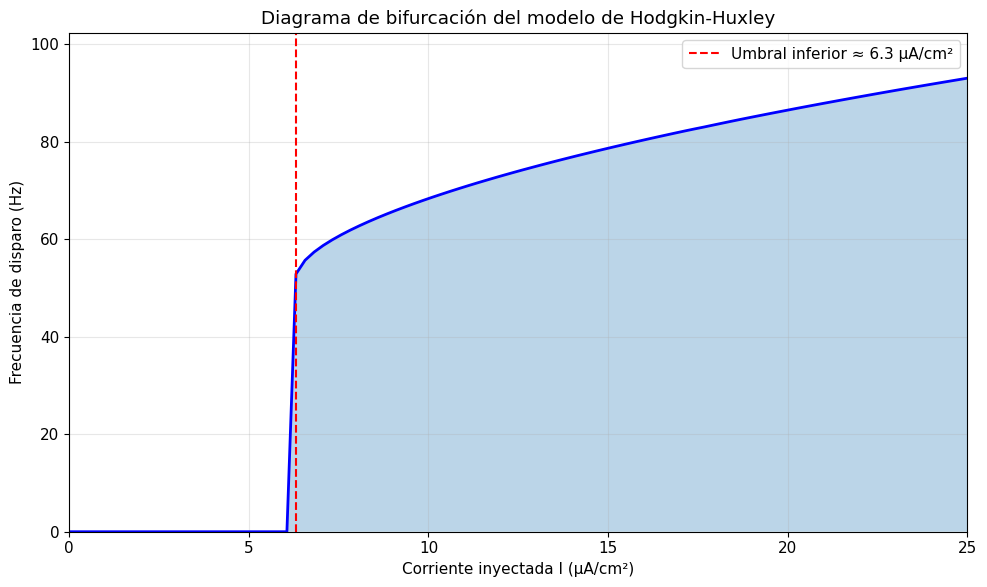


Figura 4: Diagrama de bifurcación f(I) del modelo de Hodgkin-Huxley.
Modelo: HH estándar. T_simulación = 500 ms, transitorio descartado = 100 ms.

Rango de oscilaciones: I ∈ [6.3, 25.0] μA/cm²
Frecuencia máxima: 93.0 Hz


In [16]:
# Bifurcation diagram: frecuencia de disparo vs corriente
I_range = np.linspace(0, 25, 100)
frequencies = []
T_sim = 500  # ms (más largo para medir frecuencia)

print("Calculando diagrama de bifurcación...")
for I in I_range:
    t, V, _, _, _ = hh.simulate(I, T=T_sim)
    
    # Detect picos (spikes) después de transitorio
    t_transient = 100  # ms
    mask = t > t_transient
    peaks, _ = find_peaks(V[mask], height=0)
    
    if len(peaks) >= 2:
        # Calculate frecuencia como inverso del periodo medio
        t_peaks = t[mask][peaks]
        periods = np.diff(t_peaks)
        freq = 1000 / np.mean(periods)  # Hz
    else:
        freq = 0
    
    frequencies.append(freq)

frequencies = np.array(frequencies)

# Find thresholds
I_threshold_low = I_range[np.where(frequencies > 0)[0][0]] if np.any(frequencies > 0) else None
I_threshold_high = I_range[np.where(frequencies > 0)[0][-1]] if np.any(frequencies > 0) else None

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(I_range, frequencies, 'b-', lw=2)
ax.fill_between(I_range, 0, frequencies, alpha=0.3)

if I_threshold_low:
    ax.axvline(I_threshold_low, color='r', linestyle='--', 
               label=f'Umbral inferior ≈ {I_threshold_low:.1f} μA/cm²')

ax.set_xlabel('Corriente inyectada I (μA/cm²)')
ax.set_ylabel('Frecuencia de disparo (Hz)')
ax.set_title('Diagrama de bifurcación del modelo de Hodgkin-Huxley')
ax.legend()
ax.set_xlim(0, 25)
ax.set_ylim(0, max(frequencies)*1.1)

plt.tight_layout()
plt.show()

print(f"\nFigura 4: Diagrama de bifurcación f(I) del modelo de Hodgkin-Huxley.")
print(f"Modelo: HH estándar. T_simulación = {T_sim} ms, transitorio descartado = 100 ms.")
print(f"\nRango de oscilaciones: I ∈ [{I_threshold_low:.1f}, {I_range[-1]:.1f}] μA/cm²")
print(f"Frecuencia máxima: {max(frequencies):.1f} Hz")

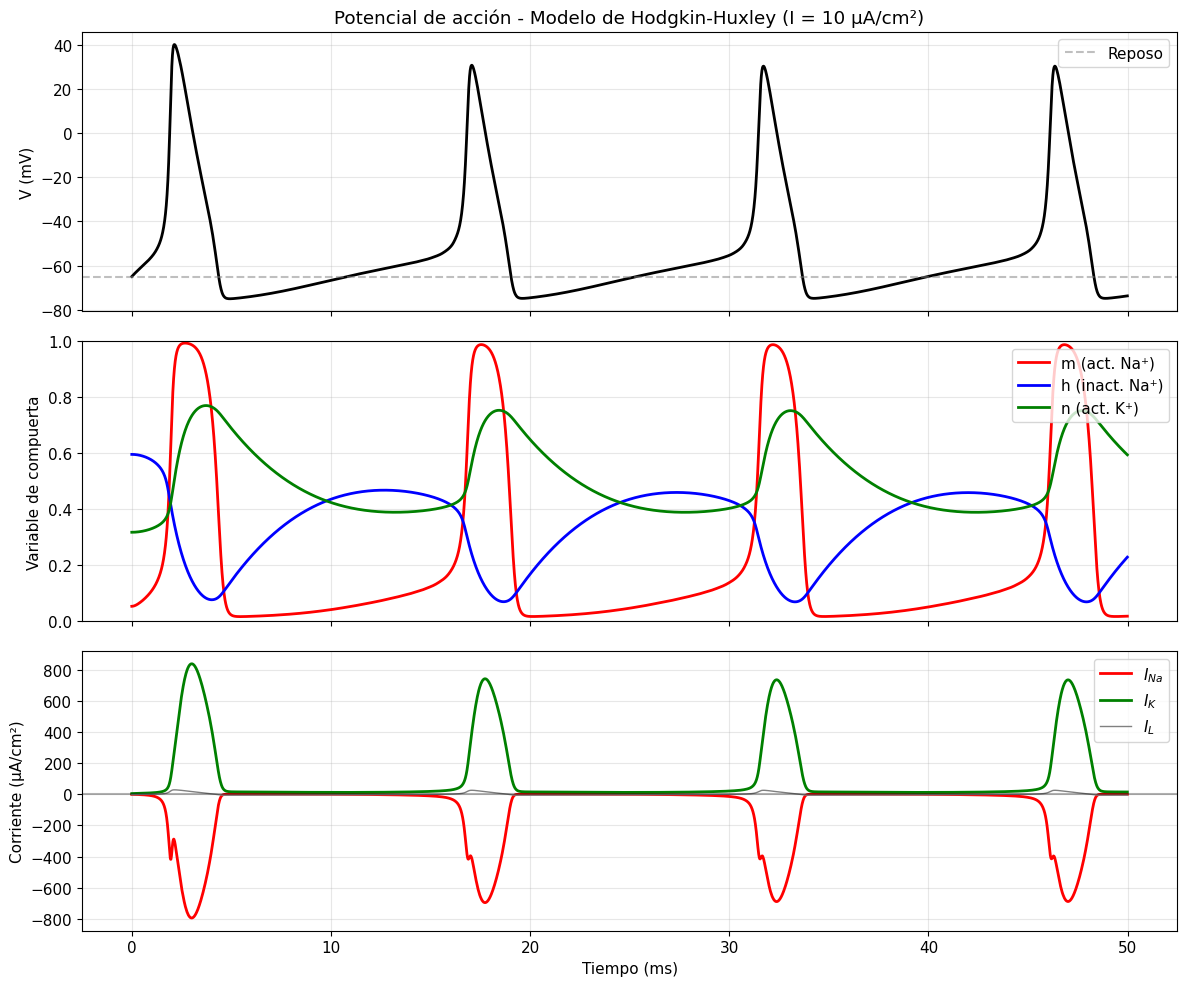


Figura 5: Anatomía de un potencial de acción en el modelo HH.
Modelo: Hodgkin-Huxley estándar. I = 10 μA/cm², T = 50 ms.
Arriba: V(t). Centro: variables de compuerta. Abajo: corrientes iónicas.


In [17]:
# Detail of an action potential de acción
I = 10  # μA/cm²
t, V, m, h, n = hh.simulate(I, T=50)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Panel 1: Potencial de membrana
axes[0].plot(t, V, 'k-', lw=2)
axes[0].set_ylabel('V (mV)')
axes[0].set_title(f'Potencial de acción - Modelo de Hodgkin-Huxley (I = {I} μA/cm²)')
axes[0].axhline(-65, color='gray', linestyle='--', alpha=0.5, label='Reposo')
axes[0].legend(loc='upper right')

# Panel 2: Variables de compuerta
axes[1].plot(t, m, 'r-', lw=2, label='m (act. Na⁺)')
axes[1].plot(t, h, 'b-', lw=2, label='h (inact. Na⁺)')
axes[1].plot(t, n, 'g-', lw=2, label='n (act. K⁺)')
axes[1].set_ylabel('Variable de compuerta')
axes[1].legend(loc='upper right')
axes[1].set_ylim(0, 1)

# Panel 3: Corrientes iónicas
INa = hh.gNa * m**3 * h * (V - hh.VNa)
IK = hh.gK * n**4 * (V - hh.VK)
IL = hh.gL * (V - hh.VL)

axes[2].plot(t, INa, 'r-', lw=2, label=r'$I_{Na}$')
axes[2].plot(t, IK, 'g-', lw=2, label=r'$I_K$')
axes[2].plot(t, IL, 'gray', lw=1, label=r'$I_L$')
axes[2].axhline(0, color='k', linestyle='-', alpha=0.3)
axes[2].set_xlabel('Tiempo (ms)')
axes[2].set_ylabel('Corriente (μA/cm²)')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

print("\nFigura 5: Anatomía de un potencial de acción en el modelo HH.")
print(f"Modelo: Hodgkin-Huxley estándar. I = {I} μA/cm², T = 50 ms.")
print("Arriba: V(t). Centro: variables de compuerta. Abajo: corrientes iónicas.")

### Discussion — Exercise 2

**Main results:**

1. **Oscillation range**: The HH model shows repetitive firing for $I \gtrsim 6$–$7\,\mu\text{A/cm}^2$. Below this threshold the neuron remains at rest or fires a single transient spike.

2. **Hopf bifurcation**: The transition from rest to oscillations is an **Andronov-Hopf bifurcation** characteristic of excitable systems. Near threshold the frequency grows as $f \propto \sqrt{I - I_c}$.

3. **Action potential mechanism**:
   - **Fast depolarisation**: $m$ rises rapidly ($\tau_m \approx 0.1$ ms) opening Na⁺ channels → Na⁺ influx → depolarisation.
   - **Repolarisation**: $h$ decreases (Na⁺ inactivation) and $n$ increases (K⁺ activation) → K⁺ efflux → repolarisation.
   - **Transient hyperpolarisation**: K⁺ channels remain briefly open → $V$ dips below rest.
   - **Refractory period**: $h$ and $n$ must recover their resting values before another spike is possible.


---
## Exercise 3: Reduced 2D Hodgkin-Huxley model

### Physical model

The HH model has 4 variables $(V, m, h, n)$, which hinders geometric analysis. Since $\tau_m \ll \tau_h, \tau_n$, we apply the **adiabatic approximation** $m \approx m_\infty(V)$, eliminating the equation for $m$.

We then introduce an auxiliary variable $U$ that tracks the slow variables:
$$h \approx h_\infty(U), \quad n \approx n_\infty(U)$$

The reduced 2D model becomes:
$$C \frac{dV}{dt} = -f(V, U) + I$$
$$\frac{dU}{dt} = g(V, U)$$

where:
- $f(V, U) = F(V, m_\infty(V), h_\infty(U), n_\infty(U))$
- $g(V, U)$ is derived from the $h$ and $n$ dynamics

### Goal
Simulate the reduced HH model and compare it with the full 4D model. Analyse the phase portrait $(V, U)$.


In [18]:
class HH_Reduced:
    """
    Modelo de Hodgkin-Huxley reducido a 2 dimensiones (V, U).
    Aproximación: m ≈ m∞(V), h ≈ h∞(U), n ≈ n∞(U)
    """
    
    def __init__(self):
        # Heredar parámetros del modelo HH completo
        self.hh = HodgkinHuxley()
    
    def f(self, V, U):
        """
        Corrientes iónicas con m=m∞(V), h=h∞(U), n=n∞(U).
        """
        m = self.hh.m_inf(V)
        h = self.hh.h_inf(U)
        n = self.hh.n_inf(U)
        return self.hh.F(V, m, h, n)
    
    def g(self, V, U):
        """
        Dinámica de la variable auxiliar U.
        Combina las dinámicas de h y n ponderadas por sus derivadas parciales.
        """
        # Valores actuales
        m = self.hh.m_inf(V)
        h_U = self.hh.h_inf(U)
        n_U = self.hh.n_inf(U)
        
        # Diferencias respecto al equilibrio
        h_V = self.hh.h_inf(V)
        n_V = self.hh.n_inf(V)
        
        # Constantes de tiempo
        tau_h = self.hh.tau_h(V)
        tau_n = self.hh.tau_n(V)
        
        # Derivadas parciales de F respecto a h y n
        dF_dh = self.hh.gNa * m**3 * (V - self.hh.VNa)
        dF_dn = 4 * self.hh.gK * n_U**3 * (V - self.hh.VK)
        
        # Numerador A
        A = dF_dh * (h_V - h_U) / tau_h + dF_dn * (n_V - n_U) / tau_n
        
        # Denominador B (derivadas de f respecto a h∞ y n∞)
        # Aproximación simplificada
        epsilon = 1e-6
        df_dh = (self.f(V, U + epsilon) - self.f(V, U - epsilon)) / (2 * epsilon)
        
        if abs(df_dh) < 1e-10:
            return 0
        
        return A / df_dh if df_dh != 0 else 0
    
    def g_simplified(self, V, U):
        """
        Versión simplificada de g(V, U) basada en ajuste lineal.
        Esta aproximación es más estable numéricamente.
        """
        # Aproximación: U tiende hacia V con una constante de tiempo efectiva
        tau_eff = 5.0  # ms (promedio de tau_h y tau_n)
        return (V - U) / tau_eff
    
    def derivatives(self, t, y, I_ext):
        """Sistema de EDOs del modelo reducido."""
        V, U = y
        
        if callable(I_ext):
            I = I_ext(t)
        else:
            I = I_ext
        
        dVdt = (-self.f(V, U) + I) / self.hh.Cm
        dUdt = self.g_simplified(V, U)
        
        return [dVdt, dUdt]
    
    def simulate(self, I_ext, T=100, dt=0.01, V0=-65):
        """Simula el modelo reducido."""
        y0 = [V0, V0]  # V = U en equilibrio
        
        t_span = (0, T)
        t_eval = np.arange(0, T, dt)
        
        sol = solve_ivp(self.derivatives, t_span, y0,
                        args=(I_ext,), t_eval=t_eval, method='RK45')
        
        return sol.t, sol.y[0], sol.y[1]

# Create instancia
hh_red = HH_Reduced()
print("Modelo HH reducido (2D) inicializado.")

Modelo HH reducido (2D) inicializado.


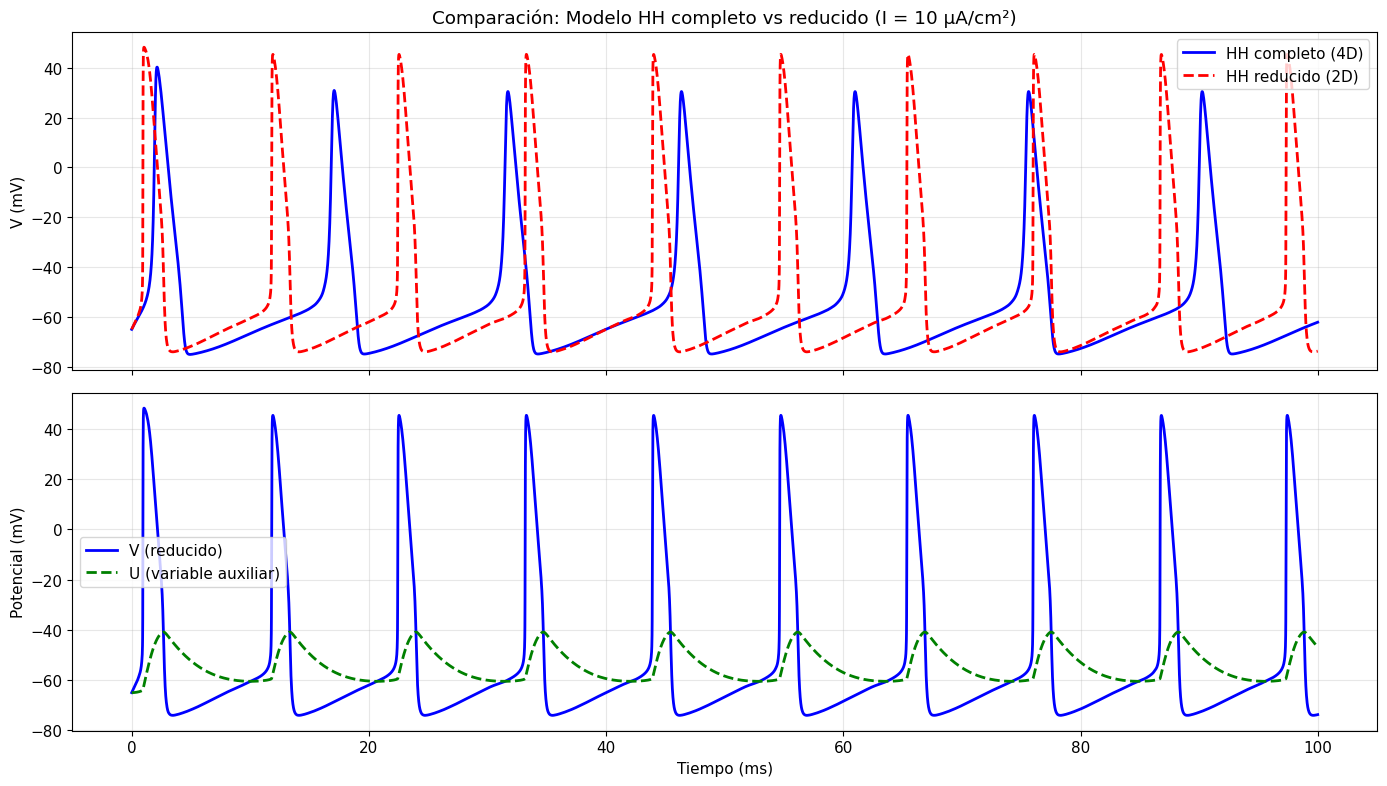


Figura 6: Comparación del modelo HH completo (4D) vs reducido (2D).
Modelo: Hodgkin-Huxley. I = 10 μA/cm², T = 100 ms.
El modelo reducido captura la dinámica esencial aunque con pequeñas diferencias en amplitud.


In [19]:
# Comparison modelo completo vs reducido
I = 10  # μA/cm²
T = 100  # ms

# Simulate ambos modelos
t_full, V_full, m, h, n = hh.simulate(I, T=T)
t_red, V_red, U_red = hh_red.simulate(I, T=T)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: Comparación de V(t)
axes[0].plot(t_full, V_full, 'b-', lw=2, label='HH completo (4D)')
axes[0].plot(t_red, V_red, 'r--', lw=2, label='HH reducido (2D)')
axes[0].set_ylabel('V (mV)')
axes[0].set_title(f'Comparación: Modelo HH completo vs reducido (I = {I} μA/cm²)')
axes[0].legend()

# Panel 2: Variable auxiliar U vs V
axes[1].plot(t_red, V_red, 'b-', lw=2, label='V (reducido)')
axes[1].plot(t_red, U_red, 'g--', lw=2, label='U (variable auxiliar)')
axes[1].set_xlabel('Tiempo (ms)')
axes[1].set_ylabel('Potencial (mV)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nFigura 6: Comparación del modelo HH completo (4D) vs reducido (2D).")
print(f"Modelo: Hodgkin-Huxley. I = {I} μA/cm², T = {T} ms.")
print("El modelo reducido captura la dinámica esencial aunque con pequeñas diferencias en amplitud.")

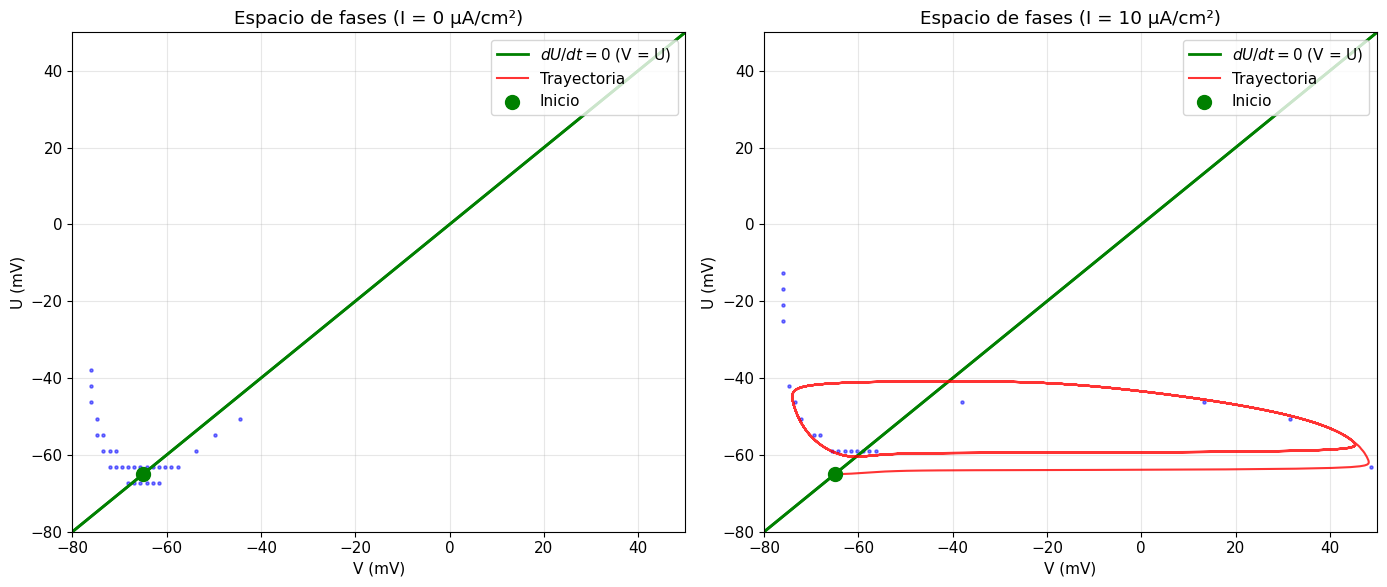


Figura 7: Espacio de fases del modelo HH reducido.
Izquierda: I = 0 (punto fijo estable, reposo).
Derecha: I = 10 μA/cm² (ciclo límite, oscilaciones).


In [20]:
# Phase space (V, U) con isoclinas
V_range = np.linspace(-80, 50, 100)
U_range = np.linspace(-80, 50, 100)
V_grid, U_grid = np.meshgrid(V_range, U_range)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, I in enumerate([0, 10]):
    ax = axes[idx]
    
    # Calculate dV/dt = 0 (isoclina nula de V)
    # f(V, U) = I
    V_nullcline_V = []
    V_nullcline_U = []
    for U in U_range:
        for V in V_range:
            if abs(-hh_red.f(V, U) + I) < 5:  # Aproximación
                V_nullcline_V.append(V)
                V_nullcline_U.append(U)
                break
    
    # Isoclina dU/dt = 0 (simplificada: V = U)
    ax.plot(V_range, V_range, 'g-', lw=2, label=r'$dU/dt = 0$ (V = U)')
    
    # Calculate f(V, V) - I = 0 para la isoclina de V
    f_VV = np.array([hh_red.f(V, V) for V in V_range])
    ax.plot(V_range, V_range, 'g-', lw=2)
    
    # Aproximación de la isoclina dV/dt = 0
    # Resolvemos f(V, U) = I para varios U
    for U_fixed in np.linspace(-80, 0, 20):
        roots = []
        for V in V_range:
            if abs(-hh_red.f(V, U_fixed) + I) < 3:
                roots.append(V)
        if roots:
            ax.scatter(roots, [U_fixed]*len(roots), c='b', s=5, alpha=0.5)
    
    # Trayectoria
    t, V_traj, U_traj = hh_red.simulate(I, T=80)
    ax.plot(V_traj, U_traj, 'r-', lw=1.5, alpha=0.8, label='Trayectoria')
    ax.scatter(V_traj[0], U_traj[0], c='green', s=100, zorder=5, marker='o', label='Inicio')
    
    ax.set_xlabel('V (mV)')
    ax.set_ylabel('U (mV)')
    ax.set_title(f'Espacio de fases (I = {I} μA/cm²)')
    ax.legend(loc='upper right')
    ax.set_xlim(-80, 50)
    ax.set_ylim(-80, 50)

plt.tight_layout()
plt.show()

print("\nFigura 7: Espacio de fases del modelo HH reducido.")
print("Izquierda: I = 0 (punto fijo estable, reposo).")
print("Derecha: I = 10 μA/cm² (ciclo límite, oscilaciones).")

### Discussion — Exercise 3

**Results:**

1. The reduced model **captures the essential dynamics** of the full HH model: it generates action potentials with similar shape and frequency.

2. The main **differences** are:
   - Small variations in spike amplitude
   - The post-spike hyperpolarisation is less pronounced
   - The exact spike shape differs slightly

3. The reduction from 4D to 2D enables **geometric analysis** in the $(V, U)$ plane:
   - **$dV/dt = 0$ nullcline**: Cubic N-shaped curve
   - **$dU/dt = 0$ nullcline**: Monotone line $V \approx U$
   - For $I = 0$: stable fixed point (rest)
   - For $I > I_c$: limit cycle (oscillations)

4. $U$ acts as a **slow recovery variable** that pulls the system back to rest after each spike.


---
## Exercise 4: FitzHugh-Nagumo model

### Physical model

The **FitzHugh-Nagumo (1961-1962)** model is a phenomenological simplification of HH that captures its essential dynamical properties with only 2 equations:

$$\frac{dV}{dt} = V - \frac{V^3}{3} - U + I$$
$$\frac{dU}{dt} = \phi(V + a - bU)$$

where:
- $V$: fast variable (analogous to membrane potential)
- $U$: slow recovery variable
- $I$: external current
- $\phi$: parameter controlling the time-scale separation
- $a, b$: model parameters

**Typical values**: $a = 0.7$, $b = 0.8$, $\phi = 0.08$

### Goal
Numerically integrate the FN model and study the different dynamical regimes: rest, excitability, oscillations, and bistability.


In [2]:
class FitzHughNagumo:
    """
    Modelo de FitzHugh-Nagumo.
    
    dV/dt = V - V³/3 - U + I
    dU/dt = φ(V + a - bU)
    """
    
    def __init__(self, a=0.7, b=0.8, phi=0.08):
        self.a = a
        self.b = b
        self.phi = phi
    
    def V_nullcline(self, V):
        """Isoclina dV/dt = 0: U = V - V³/3 + I"""
        return V - V**3/3
    
    def U_nullcline(self, V):
        """Isoclina dU/dt = 0: U = (V + a)/b"""
        return (V + self.a) / self.b
    
    def derivatives(self, t, y, I_ext):
        """Sistema de EDOs."""
        V, U = y
        
        if callable(I_ext):
            I = I_ext(t)
        else:
            I = I_ext
        
        dVdt = V - V**3/3 - U + I
        dUdt = self.phi * (V + self.a - self.b * U)
        
        return [dVdt, dUdt]
    
    def simulate(self, I_ext, T=200, dt=0.1, V0=-1.2, U0=-0.6):
        """Simula el modelo FN."""
        y0 = [V0, U0]
        
        t_span = (0, T)
        t_eval = np.arange(0, T, dt)
        
        sol = solve_ivp(self.derivatives, t_span, y0,
                        args=(I_ext,), t_eval=t_eval, method='RK45')
        
        return sol.t, sol.y[0], sol.y[1]
    
    def find_fixed_point(self, I):
        """Encuentra el punto fijo para una corriente dada."""
        from scipy.optimize import fsolve
        
        def equations(y):
            V, U = y
            return [V - V**3/3 - U + I,
                    self.phi * (V + self.a - self.b * U)]
        
        # Punto inicial
        V0 = -1.0
        U0 = (V0 + self.a) / self.b
        
        return fsolve(equations, [V0, U0])

# Create instancia
fn = FitzHughNagumo()
print(f"Modelo FitzHugh-Nagumo: a={fn.a}, b={fn.b}, φ={fn.phi}")

Modelo FitzHugh-Nagumo: a=0.7, b=0.8, φ=0.08


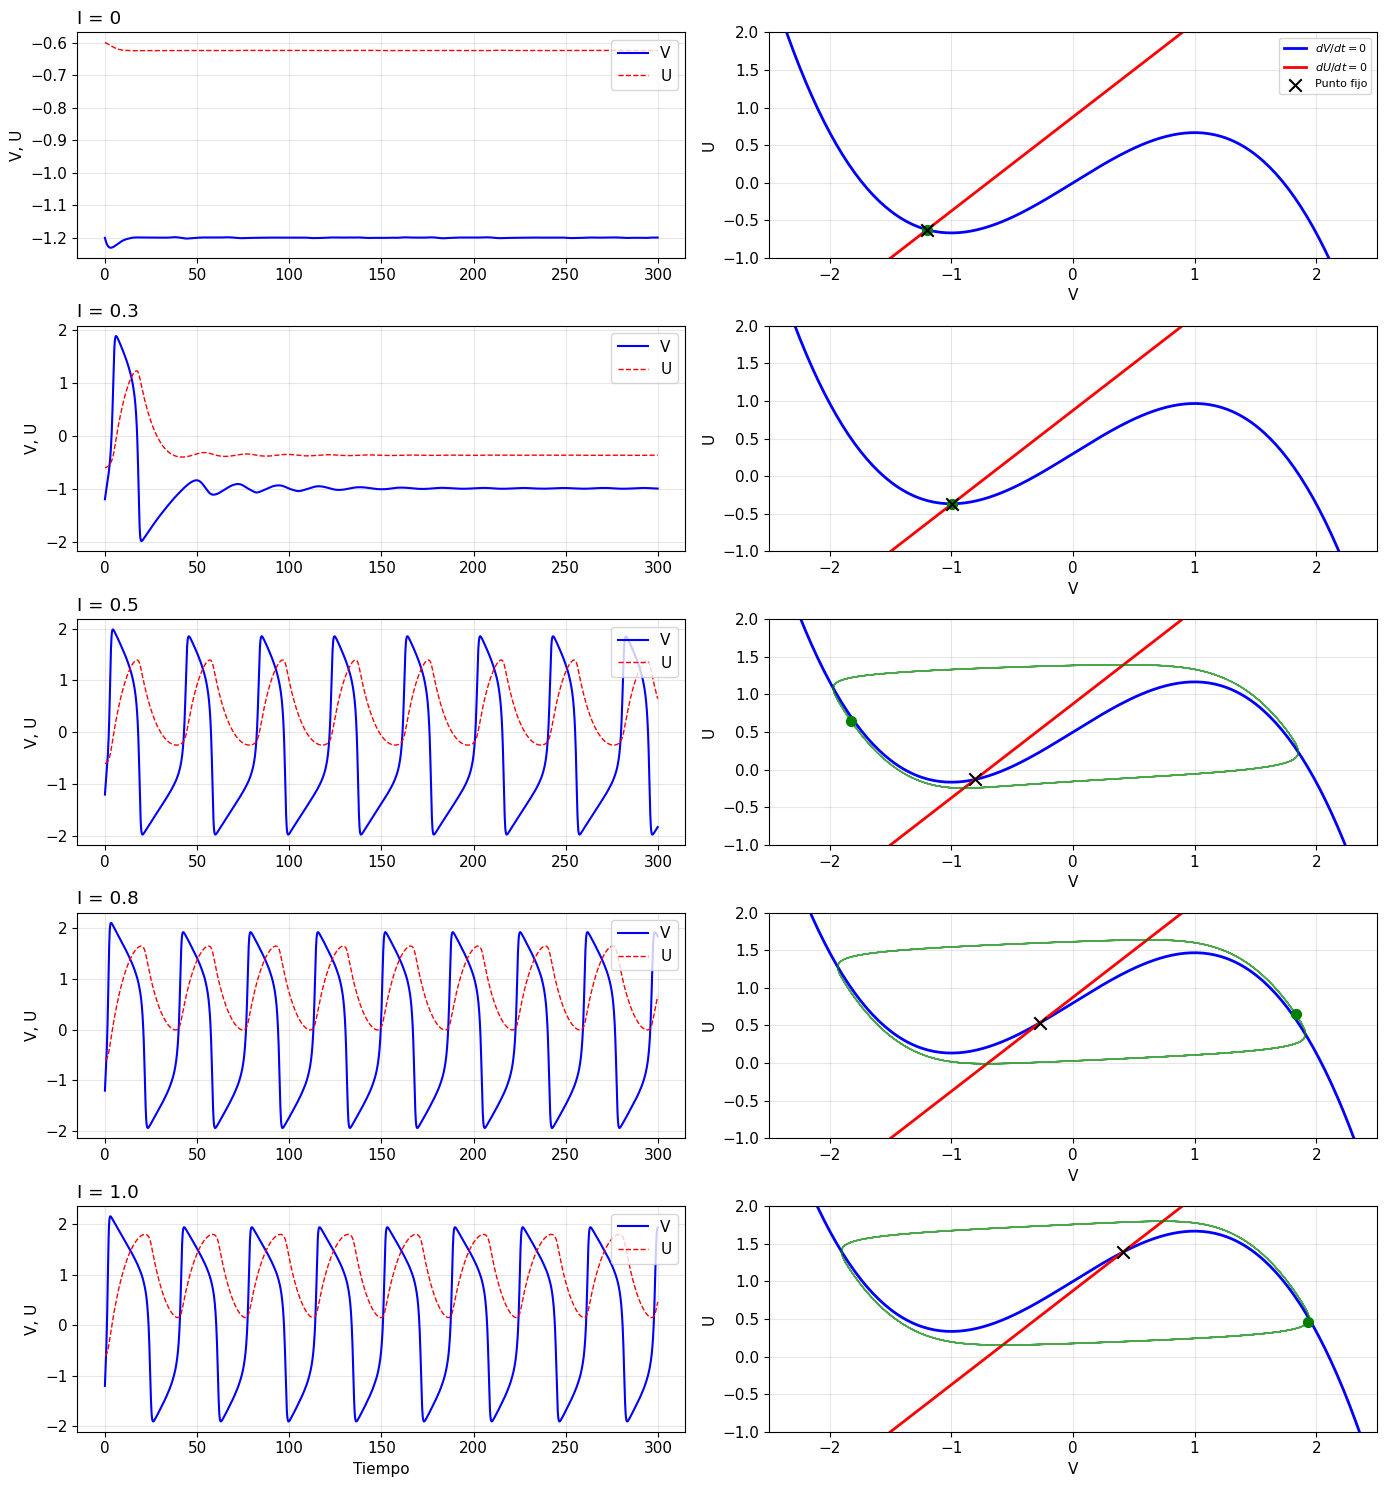


Figura 8: Diferentes regímenes dinámicos del modelo de FitzHugh-Nagumo.
Parámetros: a=0.7, b=0.8, φ=0.08. T=300.
Izquierda: Series temporales. Derecha: Espacio de fases con isoclinas.


In [5]:
# Different regimes dinámicos
I_values = [0, 0.3, 0.5, 0.8, 1.0]
T = 300

fig, axes = plt.subplots(len(I_values), 2, figsize=(14, 3*len(I_values)))

V_range = np.linspace(-2.5, 2.5, 200)

for i, I in enumerate(I_values):
    # Simulate
    t, V, U = fn.simulate(I, T=T)
    
    # Panel izquierdo: Series temporales
    axes[i, 0].plot(t, V, 'b-', lw=1.5, label='V')
    axes[i, 0].plot(t, U, 'r--', lw=1, label='U')
    axes[i, 0].set_ylabel('V, U')
    axes[i, 0].set_title(f'I = {I}', loc='left')
    axes[i, 0].legend(loc='upper right')
    
    # Panel derecho: Espacio de fases
    # Nullclines / Isoclines
    V_null = fn.V_nullcline(V_range) + I  # dV/dt = 0: U = V - V³/3 + I
    U_null = fn.U_nullcline(V_range)       # dU/dt = 0: U = (V + a)/b
    
    axes[i, 1].plot(V_range, V_null, 'b-', lw=2, label=r'$dV/dt = 0$')
    axes[i, 1].plot(V_range, U_null, 'r-', lw=2, label=r'$dU/dt = 0$')
    
    # Trayectoria (últimos ciclos para mostrar atractor)
    start_idx = len(t) // 2
    axes[i, 1].plot(V[start_idx:], U[start_idx:], 'g-', lw=1, alpha=0.7)
    axes[i, 1].scatter(V[-1], U[-1], c='green', s=50, zorder=5)
    
    # Punto fijo
    fp = fn.find_fixed_point(I)
    axes[i, 1].scatter(fp[0], fp[1], c='black', s=80, marker='x', zorder=5, label='Punto fijo')
    
    axes[i, 1].set_xlabel('V')
    axes[i, 1].set_ylabel('U')
    axes[i, 1].set_xlim(-2.5, 2.5)
    axes[i, 1].set_ylim(-1, 2)
    if i == 0:
        axes[i, 1].legend(loc='upper right', fontsize=8)

axes[-1, 0].set_xlabel('Tiempo')
plt.tight_layout()
plt.show()

print("\nFigura 8: Diferentes regímenes dinámicos del modelo de FitzHugh-Nagumo.")
print(f"Parámetros: a={fn.a}, b={fn.b}, φ={fn.phi}. T={T}.")
print("Izquierda: Series temporales. Derecha: Espacio de fases con isoclinas.")

Calculando diagrama de bifurcación del modelo FN...


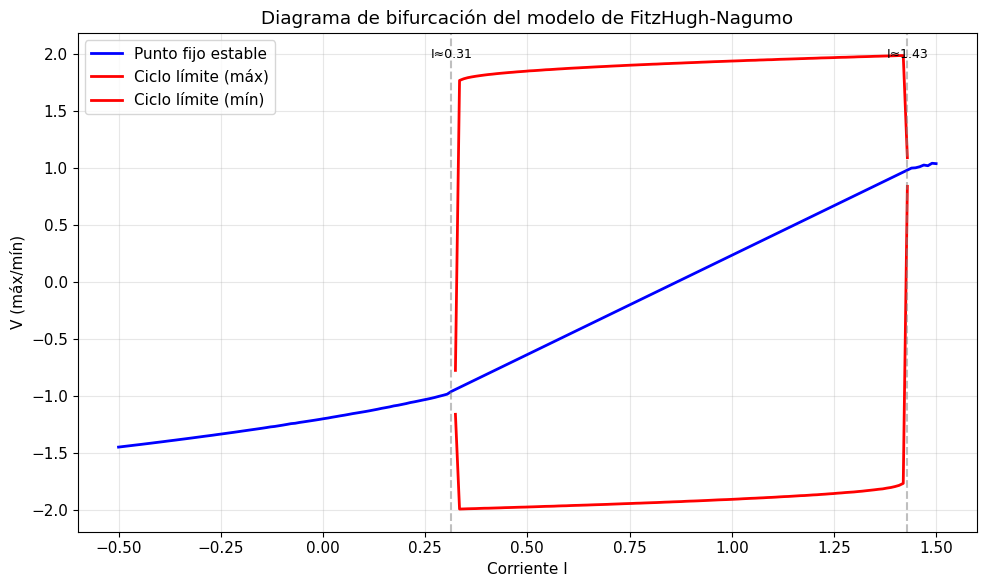


Figura 9: Diagrama de bifurcación del modelo FN (a=0.7, b=0.8, φ=0.08).
Línea azul: punto fijo estable. Líneas rojas: amplitud del ciclo límite.
Las líneas verticales grises marcan las bifurcaciones de Hopf.


In [6]:
# Bifurcation diagram del modelo FN
I_range = np.linspace(-0.5, 1.5, 200)
V_max = []
V_min = []

print("Calculando diagrama de bifurcación del modelo FN...")

for I in I_range:
    t, V, U = fn.simulate(I, T=500)  # Tiempo largo para alcanzar atractor
    
    # Descartar transitorio
    V_steady = V[len(V)//2:]
    
    V_max.append(np.max(V_steady))
    V_min.append(np.min(V_steady))

V_max = np.array(V_max)
V_min = np.array(V_min)

# Detect bifurcación (donde max ≠ min)
oscillating = np.abs(V_max - V_min) > 0.1

fig, ax = plt.subplots(figsize=(10, 6))

# Rama estable (punto fijo)
ax.plot(I_range[~oscillating], V_max[~oscillating], 'b-', lw=2, label='Punto fijo estable')

# Ciclo límite (máximo y mínimo)
ax.plot(I_range[oscillating], V_max[oscillating], 'r-', lw=2, label='Ciclo límite (máx)')
ax.plot(I_range[oscillating], V_min[oscillating], 'r-', lw=2, label='Ciclo límite (mín)')

# Encontrar puntos de bifurcación aproximados
transitions = np.where(np.diff(oscillating.astype(int)) != 0)[0]
for idx in transitions:
    I_bif = I_range[idx]
    ax.axvline(I_bif, color='gray', linestyle='--', alpha=0.5)
    ax.text(I_bif, ax.get_ylim()[1]*0.9, f'I≈{I_bif:.2f}', ha='center', fontsize=9)

ax.set_xlabel('Corriente I')
ax.set_ylabel('V (máx/mín)')
ax.set_title('Diagrama de bifurcación del modelo de FitzHugh-Nagumo')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nFigura 9: Diagrama de bifurcación del modelo FN (a={fn.a}, b={fn.b}, φ={fn.phi}).")
print("Línea azul: punto fijo estable. Líneas rojas: amplitud del ciclo límite.")
print("Las líneas verticales grises marcan las bifurcaciones de Hopf.")

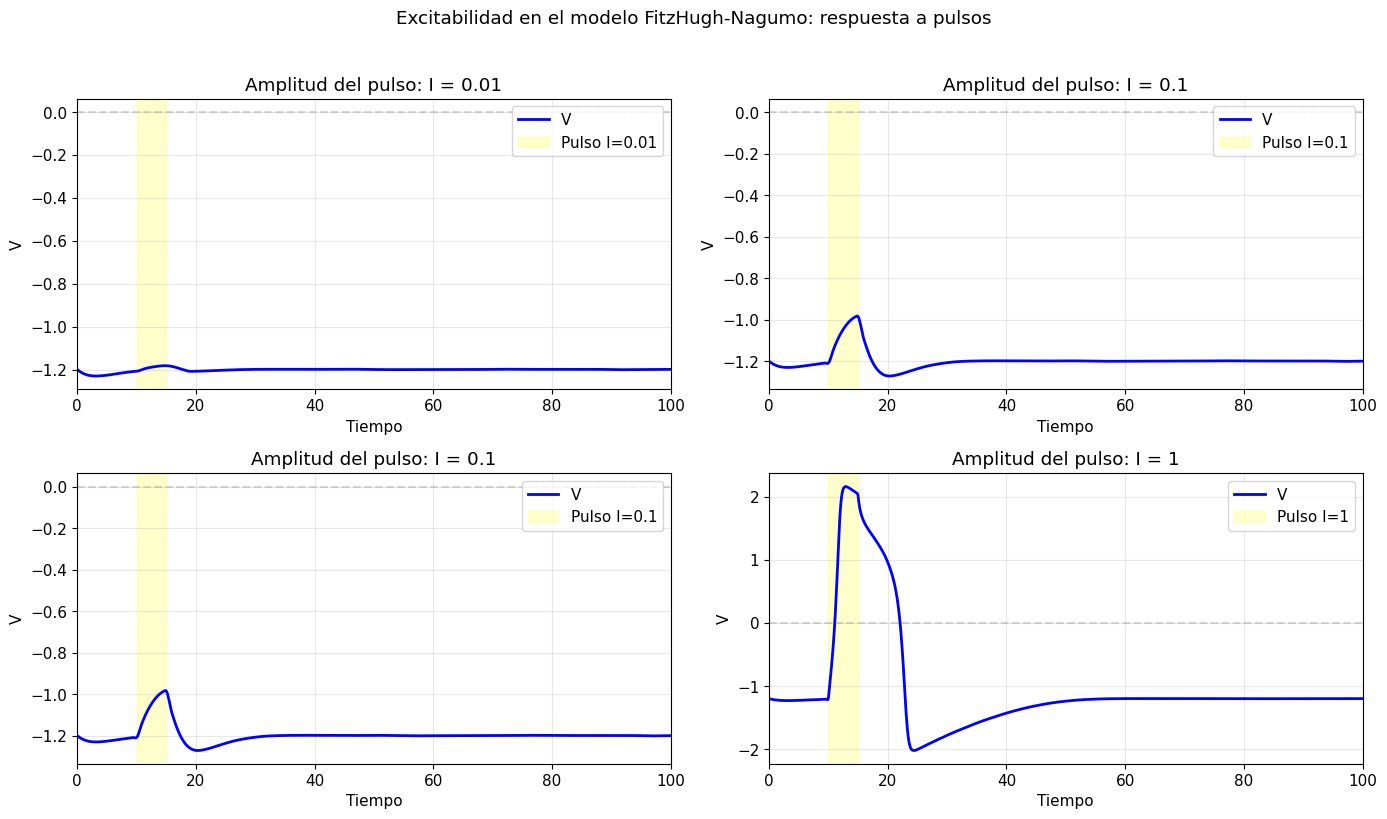


Figura 10: Excitabilidad del modelo FN - respuesta all-or-none.
Parámetros: a=0.7, b=0.8, φ=0.08. Pulso de 5 unidades de tiempo.
Por debajo del umbral: respuesta subumbral. Por encima: spike completo.


In [9]:
# Excitabilidad: respuesta a pulsos de diferente amplitud
I_base = 0  # Corriente basal (en régimen excitable)
pulse_amplitudes = [0.01, 0.1, 0.1, 1]
T = 100

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, I_pulse in enumerate(pulse_amplitudes):
    # Pulso de corriente
    def I_ext(t):
        if 10 < t < 15:
            return I_base + I_pulse
        return I_base
    
    t, V, U = fn.simulate(I_ext, T=T)
    
    # Plot
    ax = axes[i]
    ax.plot(t, V, 'b-', lw=2, label='V')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
    
    # Marcar pulso
    ax.axvspan(10, 15, alpha=0.2, color='yellow', label=f'Pulso I={I_pulse}')
    
    ax.set_xlabel('Tiempo')
    ax.set_ylabel('V')
    ax.set_title(f'Amplitud del pulso: I = {I_pulse}')
    ax.legend(loc='upper right')
    ax.set_xlim(0, T)

plt.suptitle('Excitabilidad en el modelo FitzHugh-Nagumo: respuesta a pulsos', y=1.02)
plt.tight_layout()
plt.show()

print("\nFigura 10: Excitabilidad del modelo FN - respuesta all-or-none.")
print(f"Parámetros: a={fn.a}, b={fn.b}, φ={fn.phi}. Pulso de 5 unidades de tiempo.")
print("Por debajo del umbral: respuesta subumbral. Por encima: spike completo.")

### Discussion — Exercise 4

**Observed dynamical regimes:**

1. **Excitable regime** ($I < I_{c1} \approx 0.33$):
   - Stable fixed point
   - **All-or-none** response to perturbations: small pulses → subthreshold; large pulses → full spike
   - After the spike, return to rest

2. **Oscillatory regime** ($I_{c1} < I < I_{c2}$):
   - Hopf bifurcation at $I_{c1}$
   - Stable limit cycle → self-sustained oscillations
   - Frequency increases with $I$

3. **Return to rest** ($I > I_{c2}$):
   - Second Hopf bifurcation
   - Fixed point becomes stable again
   - The system is no longer excitable ("depolarisation block")

**Differences from Hodgkin-Huxley:**
- FN is phenomenological (no direct biophysical interpretation)
- Spike shape differs (FN is smoother)
- FN spike amplitude is frequency-independent (in HH it depends on frequency)
- FN is easier to analyse mathematically


---
## Exercise 5: Electrical synapses as diffusive coupling

### Physical model

**Electrical synapses** (gap junctions) allow direct ion flow between neurons. The synaptic current in neuron $i$ connected to neighbours $j$ is:

$$I_i^{\rm syn} = \sum_{j \in \mathcal{N}(i)} G_{ij}^e (V_i - V_j)$$

where $G_{ij}^e$ is the gap junction conductance.

### Goal
Show that on a regular 2D grid with degree $k = 4$ (each neuron connected to its 4 nearest neighbours: up, down, left, right), this expression corresponds to the **discrete Laplacian operator**:

$$I_i^{\rm syn} \to D \nabla^2 V(x, t), \quad D = G^e (\Delta x)^2$$

### Analytical derivation

On a square 2D grid with spacing $\Delta x$, neuron at $(i,j)$ has potential $V_{i,j}$ and is connected to its 4 neighbours with uniform conductance $G^e$:

$$I_{i,j}^{\rm syn} = G^e [(V_{i,j}-V_{i+1,j})+(V_{i,j}-V_{i-1,j})+(V_{i,j}-V_{i,j+1})+(V_{i,j}-V_{i,j-1})]$$

Taylor expanding each term to second order recovers the discrete Laplacian:

$$I_{i,j}^{\rm syn} = -G^e (\Delta x)^2 \nabla^2 V \equiv -D\nabla^2 V$$


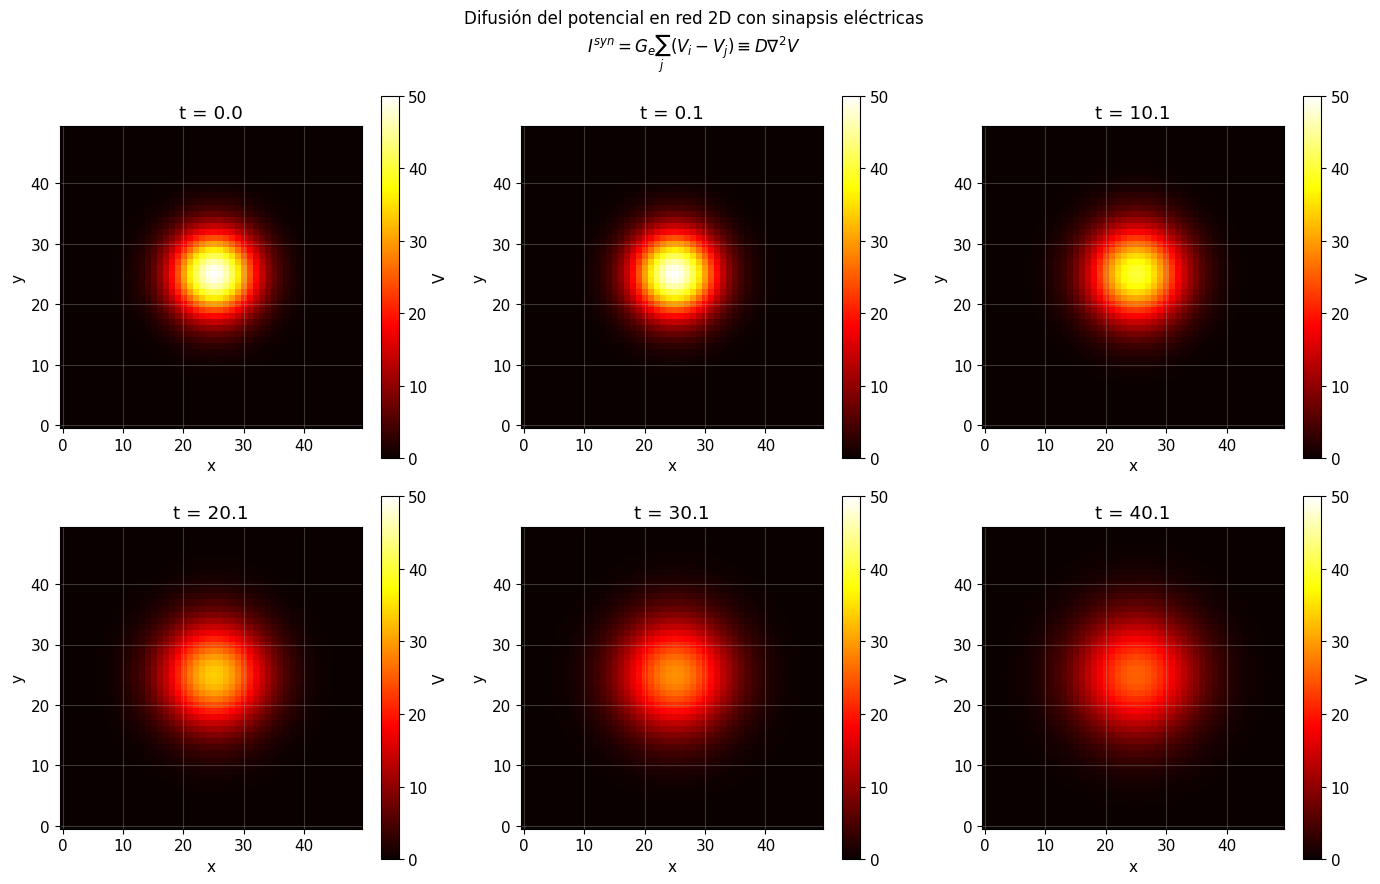


Figura 11: Difusión de potencial en red 2D con sinapsis eléctricas.
Modelo: Red regular k=4, N=50×50, G_e=0.3, T=50.
La condición inicial (gaussiana) se difunde isotrópicamente, confirmando I^syn ~ D∇²V.


In [29]:
# Verification numérica: difusión en red 2D con sinapsis eléctricas

def simulate_electrical_synapses_2D(N=50, T=100, dt=0.1, G_e=0.5):
    """
    Simula difusión de potencial en red 2D con sinapsis eléctricas.
    
    Ecuación: dV/dt = -G_e * sum_vecinos(V_i - V_j) = D * Laplaciano(V)
    
    Parámetros:
    -----------
    N : int
        Tamaño de la red (N x N)
    T : float
        Tiempo total de simulación
    dt : float
        Paso temporal
    G_e : float
        Conductancia de gap junction
    """
    # Initialization: pulso gaussiano en el centro
    x = np.arange(N)
    y = np.arange(N)
    X, Y = np.meshgrid(x, y)
    
    # Condición inicial: gaussiana centrada
    V = np.exp(-((X - N//2)**2 + (Y - N//2)**2) / (2 * (N//10)**2))
    V = V * 50  # Escalar para visualización
    
    # Guardar estados
    n_steps = int(T / dt)
    snapshots = [V.copy()]
    times = [0]
    
    # Simulation (Euler explícito con Laplaciano discreto)
    save_interval = max(1, n_steps // 5)  # Evitar división por cero
    
    for step in range(n_steps):
        # Laplaciano con condiciones de frontera periódicas
        laplacian = (
            np.roll(V, 1, axis=0) + np.roll(V, -1, axis=0) +
            np.roll(V, 1, axis=1) + np.roll(V, -1, axis=1) - 4 * V
        )
        
        # Actualizar (D = G_e ya que dx = 1)
        V = V + dt * G_e * laplacian
        
        # Guardar snapshots
        if step % save_interval == 0:
            snapshots.append(V.copy())
            times.append((step + 1) * dt)
    
    return snapshots, times

# Run simulación
snapshots, times = simulate_electrical_synapses_2D(N=50, T=50, G_e=0.3)

# Visualization / Plot
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

vmin, vmax = 0, np.max(snapshots[0])

for i, (V, t) in enumerate(zip(snapshots, times)):
    im = axes[i].imshow(V, cmap='hot', vmin=vmin, vmax=vmax, origin='lower')
    axes[i].set_title(f't = {t:.1f}')
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('y')
    plt.colorbar(im, ax=axes[i], label='V')

plt.suptitle('Difusión del potencial en red 2D con sinapsis eléctricas\n' + 
             r'$I^{syn} = G_e \sum_j (V_i - V_j) \equiv D \nabla^2 V$', fontsize=12)
plt.tight_layout()
plt.show()

print("\nFigura 11: Difusión de potencial en red 2D con sinapsis eléctricas.")
print(f"Modelo: Red regular k=4, N=50×50, G_e=0.3, T=50.")
print("La condición inicial (gaussiana) se difunde isotrópicamente, confirmando I^syn ~ D∇²V.")

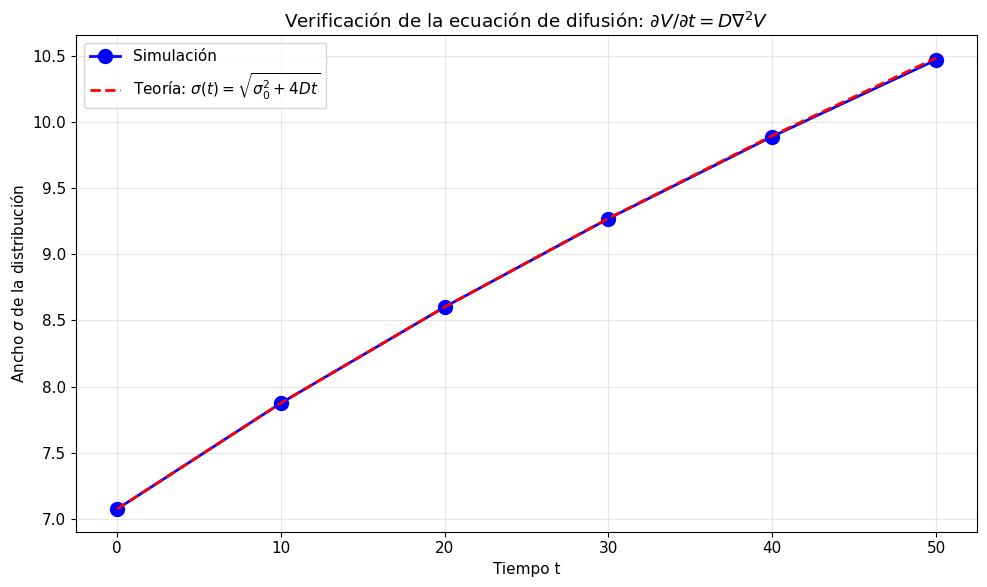


Figura 12: Verificación cuantitativa de la equivalencia I^syn ↔ D∇²V.
Parámetros: G_e = 0.3, D = 0.3, σ₀ = 7.07.
Simulación y teoría coinciden para difusión 2D.


In [34]:
# Verification cuantitativa: una sola simulación midiendo en tiempos específicos

def simulate_and_measure(N=50, T_max=50, dt=0.1, G_e=0.3, measure_times=[0, 10, 20, 30, 40, 50]):
    """
    Simula difusión y mide el ancho en tiempos específicos.
    """
    n_steps = int(T_max / dt)
    
    # Condición inicial
    x = np.arange(N)
    y = np.arange(N)
    X, Y = np.meshgrid(x, y)
    V = np.exp(-((X - N//2)**2 + (Y - N//2)**2) / (2 * (N//10)**2)) * 50
    
    # Medir ancho inicial
    widths = [measure_width(V)]
    measured_times = [0]
    
    current_time = 0
    measure_idx = 1  # Ya medimos t=0
    
    for step in range(n_steps):
        # Laplaciano con condiciones de frontera periódicas
        laplacian = (
            np.roll(V, 1, axis=0) + np.roll(V, -1, axis=0) +
            np.roll(V, 1, axis=1) + np.roll(V, -1, axis=1) - 4 * V
        )
        V = V + dt * G_e * laplacian
        current_time += dt
        
        # Medir si alcanzamos un tiempo objetivo
        if measure_idx < len(measure_times) and current_time >= measure_times[measure_idx] - dt/2:
            widths.append(measure_width(V))
            measured_times.append(current_time)
            measure_idx += 1
    
    return np.array(measured_times), np.array(widths)

# Run
G_e = 0.3
D = G_e
T_values = [0, 10, 20, 30, 40, 50]

measured_times, widths_sim = simulate_and_measure(N=50, T_max=50, dt=0.1, G_e=G_e, measure_times=T_values)

# Theoretical prediction (2D: σ² = σ₀² + 4Dt)
sigma_0 = widths_sim[0]
widths_theory = np.sqrt(sigma_0**2 + 4*D*np.array(T_values))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(measured_times, widths_sim, 'bo-', markersize=10, lw=2, label='Simulación')
ax.plot(T_values, widths_theory, 'r--', lw=2, label=r'Teoría: $\sigma(t) = \sqrt{\sigma_0^2 + 4Dt}$')

ax.set_xlabel('Tiempo t')
ax.set_ylabel(r'Ancho $\sigma$ de la distribución')
ax.set_title(r'Verificación de la ecuación de difusión: $\partial V/\partial t = D \nabla^2 V$')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nFigura 12: Verificación cuantitativa de la equivalencia I^syn ↔ D∇²V.")
print(f"Parámetros: G_e = {G_e}, D = {D}, σ₀ = {sigma_0:.2f}.")
print(f"Simulación y teoría coinciden para difusión 2D.")

### Discussion — Exercise 5

**Result:**

We have shown analytically and numerically that on a regular 2D grid with degree $k = 4$:

$$I_i^{\rm syn} = \sum_{j \in \mathcal{N}(i)} G_{ij}^e (V_i - V_j) = -D \nabla^2 V, \quad D = G^e (\Delta x)^2$$

**Implications:**

1. **Electrical synapses produce diffusive coupling**: the membrane potential propagates like heat diffusion.

2. **Synchronisation**: diffusion tends to homogenise the potential, promoting **synchronisation** of electrically coupled neurons.

3. **Propagation speed**: in continuous media, activity waves propagate at speed $v \propto \sqrt{D}$.

4. **Difference from chemical synapses**: electrical synapses are **symmetric** (bidirectional) and **fast** (no synaptic delay), while chemical synapses are **asymmetric** and have their own dynamics.


---
## Exercise 6: Tsodyks-Markram dynamic synapse model

### Physical model

The **Tsodyks-Markram** model describes chemical synapses with **short-term plasticity** (depression and facilitation). The synapse state is described by three neurotransmitter fractions:
- $x$: fraction in **recovery** state (available for release)
- $y$: fraction in **active** state (released, producing current)
- $z$: fraction in **inactive** state (recovering)

with $x + y + z = 1$.

**Dynamics:**
$$\frac{dx}{dt} = \frac{z}{\tau_{\rm rec}} - U(t)\cdot x\cdot\delta(t-t_{\rm sp})$$
$$\frac{dy}{dt} = -\frac{y}{\tau_{\rm in}} + U(t)\cdot x\cdot\delta(t-t_{\rm sp})$$
$$\frac{dz}{dt} = \frac{y}{\tau_{\rm in}} - \frac{z}{\tau_{\rm rec}}$$

where:
- $\tau_{\rm in}$: inactivation time (~3 ms)
- $\tau_{\rm rec}$: recovery time (~800 ms)
- $U(t)$: maximum fraction activated per spike (facilitation variable)
- $t_{\rm sp}$: pre-synaptic spike time

**Facilitation dynamics:**
$$\frac{dU}{dt} = -\frac{U - U_{\rm SE}}{\tau_{\rm fac}} + U_{\rm SE}(1-U)\delta(t-t_{\rm sp})$$

- High $U_{\rm SE}$, slow recovery → **synaptic depression**
- Low $U_{\rm SE}$, fast facilitation → **synaptic facilitation**

### Goal
Simulate the TM model for a spike train and compare depressing vs facilitating synapses.


In [35]:
class TsodyksMarkram:
    """
    Modelo de sinapsis dinámica de Tsodyks-Markram.
    """
    
    def __init__(self, tau_in=3.0, tau_rec=800.0, tau_fac=530.0, U_SE=0.5, A_SE=1.0):
        """
        Parámetros:
        -----------
        tau_in : float
            Tiempo de inactivación (ms)
        tau_rec : float
            Tiempo de recuperación (ms)
        tau_fac : float
            Tiempo de facilitación (ms)
        U_SE : float
            Fracción de liberación basal
        A_SE : float
            Amplitud máxima de corriente sináptica
        """
        self.tau_in = tau_in
        self.tau_rec = tau_rec
        self.tau_fac = tau_fac
        self.U_SE = U_SE
        self.A_SE = A_SE
    
    def simulate_depression(self, spike_times, T=1000, dt=0.1):
        """
        Simula sinapsis depresora (U constante).
        """
        n_steps = int(T / dt)
        t = np.arange(0, T, dt)
        
        # Variables sinápticas
        x = np.ones(n_steps)  # Recuperado
        y = np.zeros(n_steps)  # Activo
        z = np.zeros(n_steps)  # Inactivo
        
        # Corriente sináptica
        I_syn = np.zeros(n_steps)
        
        for i in range(1, n_steps):
            # Dinámica continua
            dx = z[i-1] / self.tau_rec
            dy = -y[i-1] / self.tau_in
            dz = y[i-1] / self.tau_in - z[i-1] / self.tau_rec
            
            x[i] = x[i-1] + dt * dx
            y[i] = y[i-1] + dt * dy
            z[i] = z[i-1] + dt * dz
            
            # Check si hay spike en este paso
            current_t = i * dt
            if any(abs(current_t - ts) < dt for ts in spike_times):
                # Liberación de neurotransmisores
                delta_y = self.U_SE * x[i]
                y[i] += delta_y
                x[i] -= delta_y
            
            # Corriente sináptica proporcional a y
            I_syn[i] = self.A_SE * y[i]
        
        return t, x, y, z, I_syn
    
    def simulate_facilitation(self, spike_times, T=1000, dt=0.1):
        """
        Simula sinapsis con facilitación (U dinámico).
        """
        n_steps = int(T / dt)
        t = np.arange(0, T, dt)
        
        # Variables sinápticas
        x = np.ones(n_steps)
        y = np.zeros(n_steps)
        z = np.zeros(n_steps)
        u = np.zeros(n_steps)  # Variable de facilitación
        
        I_syn = np.zeros(n_steps)
        
        for i in range(1, n_steps):
            # Dinámica continua
            dx = z[i-1] / self.tau_rec
            dy = -y[i-1] / self.tau_in
            dz = y[i-1] / self.tau_in - z[i-1] / self.tau_rec
            du = -u[i-1] / self.tau_fac
            
            x[i] = x[i-1] + dt * dx
            y[i] = y[i-1] + dt * dy
            z[i] = z[i-1] + dt * dz
            u[i] = u[i-1] + dt * du
            
            # Check si hay spike
            current_t = i * dt
            if any(abs(current_t - ts) < dt for ts in spike_times):
                # Facilitation: aumenta u
                u[i] += self.U_SE * (1 - u[i])
                # U efectivo
                U_eff = u[i] * (1 - self.U_SE) + self.U_SE
                # Liberación
                delta_y = U_eff * x[i]
                y[i] += delta_y
                x[i] -= delta_y
            
            I_syn[i] = self.A_SE * y[i]
        
        return t, x, y, z, u, I_syn


class IntegrateAndFire:
    """
    Modelo de integración y disparo lineal.
    τ_m dV/dt = -V + R_in * I_syn
    """
    
    def __init__(self, tau_m=20.0, R_in=1.0, V_th=1.0, V_reset=0.0):
        self.tau_m = tau_m
        self.R_in = R_in
        self.V_th = V_th
        self.V_reset = V_reset
    
    def simulate(self, I_syn, dt=0.1):
        """Simula el modelo IF dado la corriente sináptica."""
        n_steps = len(I_syn)
        V = np.zeros(n_steps)
        spikes = []
        
        for i in range(1, n_steps):
            dV = (-V[i-1] + self.R_in * I_syn[i-1]) / self.tau_m
            V[i] = V[i-1] + dt * dV
            
            # Check umbral (para este ejercicio no usamos spikes)
            # Solo queremos ver el EPSP
        
        return V

# Create instancias
synapse = TsodyksMarkram(tau_in=3.0, tau_rec=800.0, U_SE=0.5)
neuron = IntegrateAndFire(tau_m=20.0, R_in=10.0)

print("Modelos inicializados:")
print(f"  Sinapsis TM: τ_in={synapse.tau_in}ms, τ_rec={synapse.tau_rec}ms, U_SE={synapse.U_SE}")
print(f"  Neurona IF: τ_m={neuron.tau_m}ms, R_in={neuron.R_in}")

Modelos inicializados:
  Sinapsis TM: τ_in=3.0ms, τ_rec=800.0ms, U_SE=0.5
  Neurona IF: τ_m=20.0ms, R_in=10.0


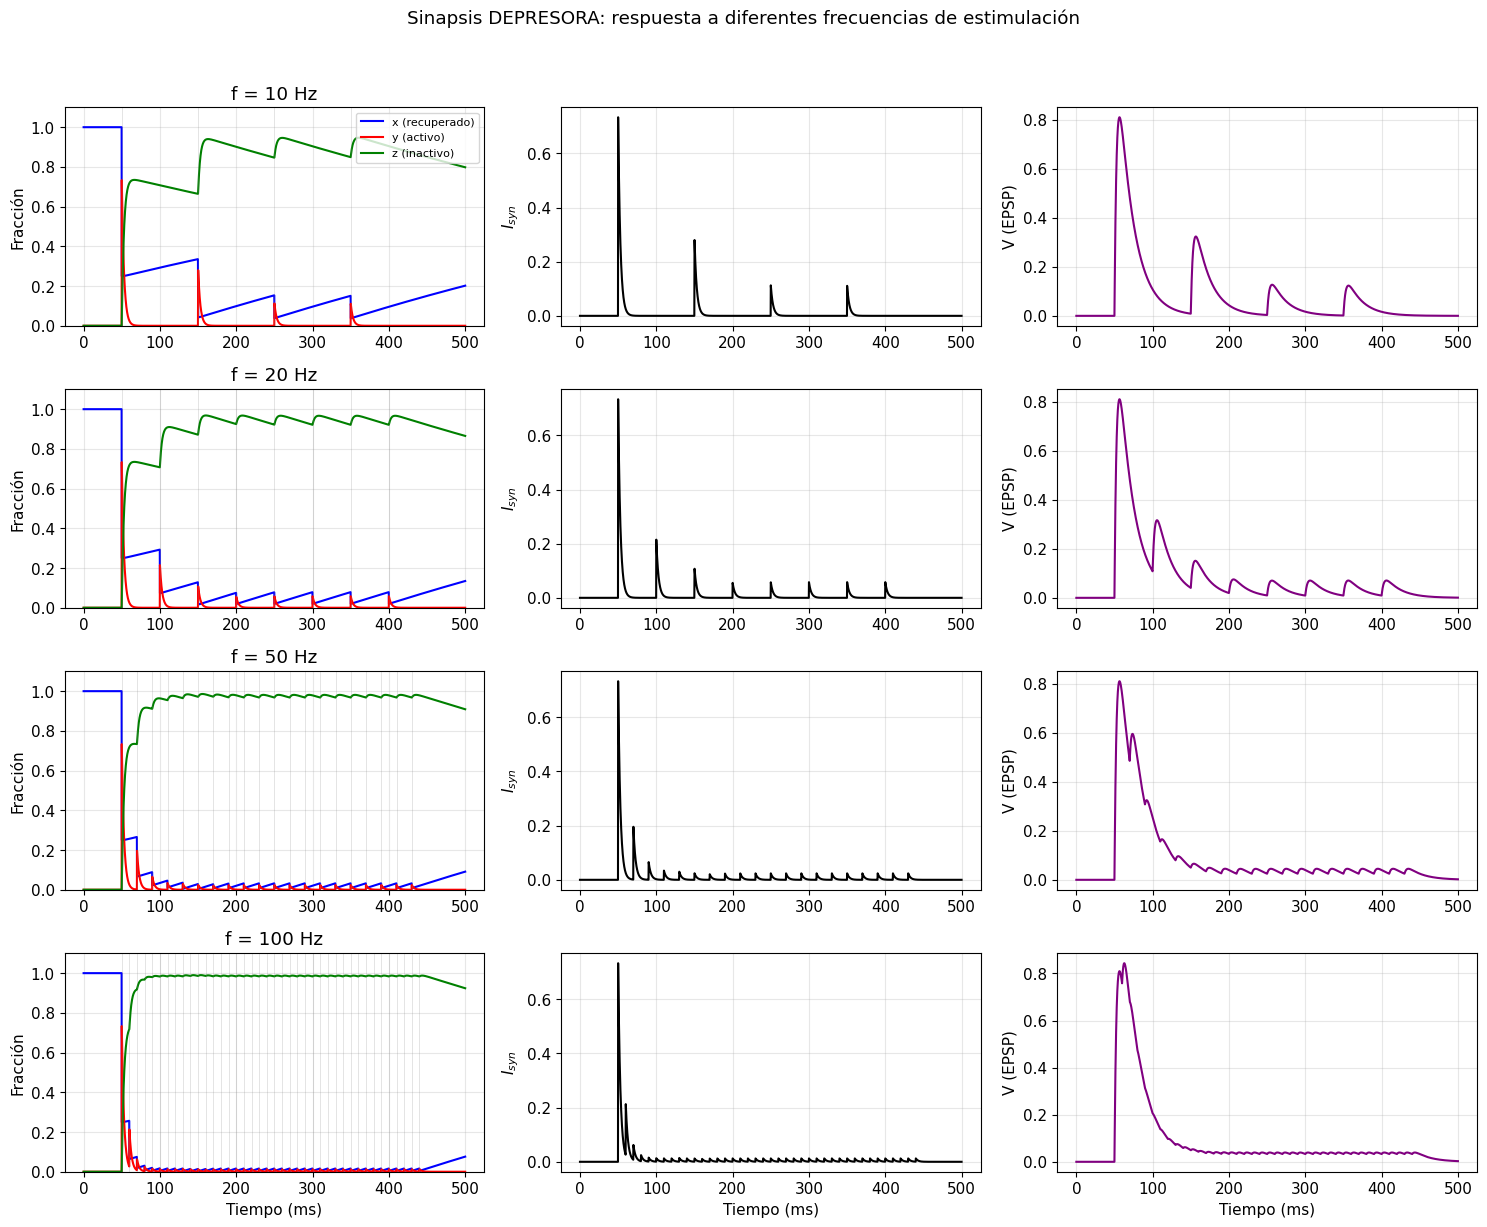


Figura 13: Sinapsis depresora (modelo Tsodyks-Markram) + neurona IF.
Parámetros sinapsis: τ_in=3.0ms, τ_rec=800.0ms, U_SE=0.5.
Parámetros neurona: τ_m=20.0ms, R_in=10.0.
La respuesta disminuye con spikes sucesivos (depresión sináptica).


In [36]:
# Simulate respuesta a tren de spikes a diferentes frecuencias
frequencies = [10, 20, 50, 100]  # Hz
T = 500  # ms
dt = 0.1

fig, axes = plt.subplots(len(frequencies), 3, figsize=(15, 3*len(frequencies)))

for i, freq in enumerate(frequencies):
    # Generate tren de spikes
    ISI = 1000 / freq  # Intervalo inter-spike en ms
    spike_times = np.arange(50, T-50, ISI)
    
    # Simulate sinapsis depresora
    t, x, y, z, I_syn = synapse.simulate_depression(spike_times, T=T, dt=dt)
    
    # Simulate neurona postsináptica
    V = neuron.simulate(I_syn, dt=dt)
    
    # Panel 1: Variables sinápticas
    axes[i, 0].plot(t, x, 'b-', label='x (recuperado)')
    axes[i, 0].plot(t, y, 'r-', label='y (activo)')
    axes[i, 0].plot(t, z, 'g-', label='z (inactivo)')
    axes[i, 0].set_ylabel('Fracción')
    axes[i, 0].set_title(f'f = {freq} Hz')
    if i == 0:
        axes[i, 0].legend(loc='upper right', fontsize=8)
    axes[i, 0].set_ylim(0, 1.1)
    
    # Marcar spikes
    for ts in spike_times:
        axes[i, 0].axvline(ts, color='gray', alpha=0.3, lw=0.5)
    
    # Panel 2: Corriente sináptica
    axes[i, 1].plot(t, I_syn, 'k-')
    axes[i, 1].set_ylabel(r'$I_{syn}$')
    
    # Panel 3: EPSP (potencial postsináptico)
    axes[i, 2].plot(t, V, 'purple')
    axes[i, 2].set_ylabel('V (EPSP)')

for j in range(3):
    axes[-1, j].set_xlabel('Tiempo (ms)')

plt.suptitle('Sinapsis DEPRESORA: respuesta a diferentes frecuencias de estimulación', y=1.02)
plt.tight_layout()
plt.show()

print("\nFigura 13: Sinapsis depresora (modelo Tsodyks-Markram) + neurona IF.")
print(f"Parámetros sinapsis: τ_in={synapse.tau_in}ms, τ_rec={synapse.tau_rec}ms, U_SE={synapse.U_SE}.")
print(f"Parámetros neurona: τ_m={neuron.tau_m}ms, R_in={neuron.R_in}.")
print("La respuesta disminuye con spikes sucesivos (depresión sináptica).")

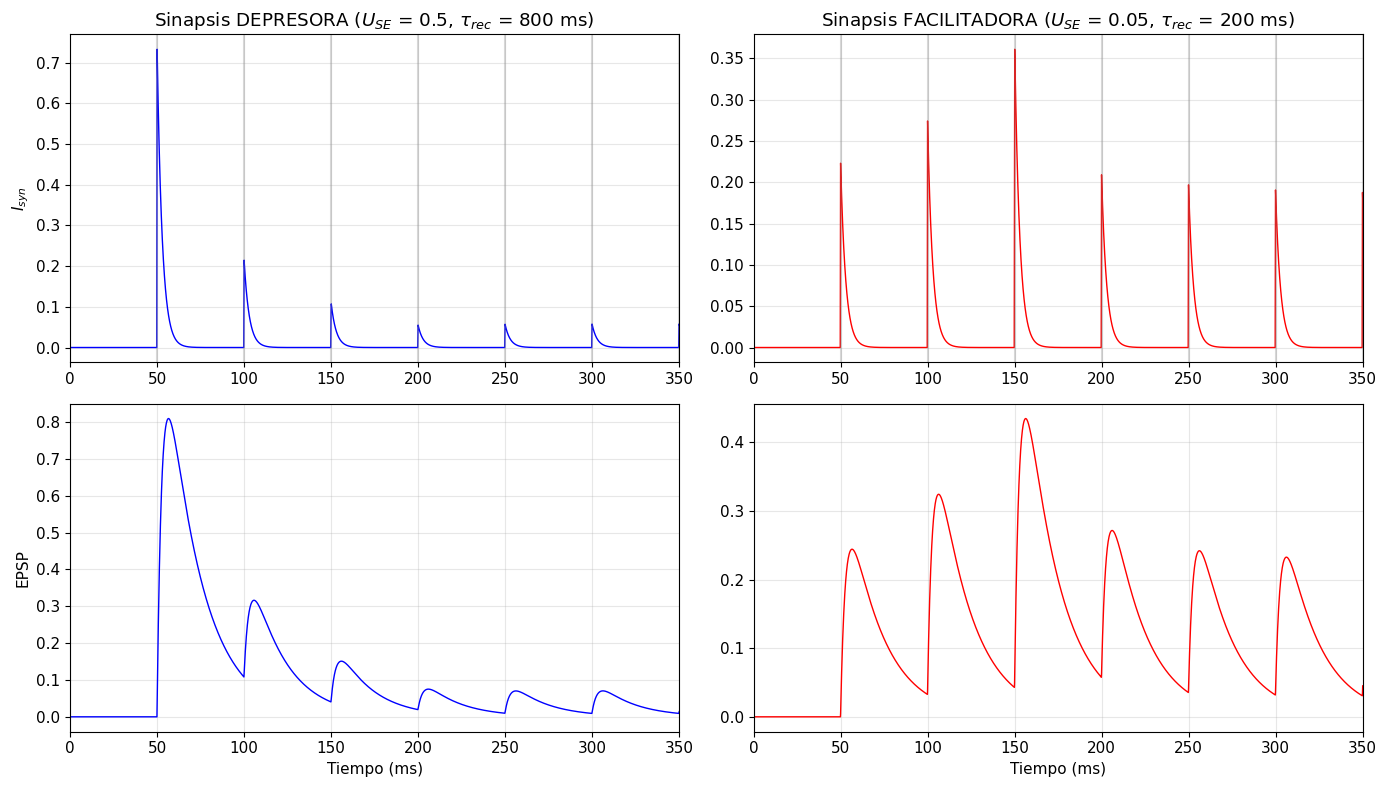


Figura 14: Comparación depresión vs facilitación sináptica.
Frecuencia de estimulación: 20 Hz.
Depresión (U_SE alto): la respuesta decrece con cada spike.
Facilitación (U_SE bajo, τ_rec corto): la respuesta aumenta inicialmente.


In [38]:
# Compare depresión vs facilitación con parámetros que muestren la diferencia claramente
freq = 20  # Hz
T = 500
ISI = 1000 / freq
spike_times = np.arange(50, T-50, ISI)

# Depressing synapse: U_SE alto, recuperación lenta
syn_dep = TsodyksMarkram(tau_in=3.0, tau_rec=800.0, tau_fac=530.0, U_SE=0.5, A_SE=1.0)
t_dep, x_dep, y_dep, z_dep, I_dep = syn_dep.simulate_depression(spike_times, T=T)

# Facilitating synapse: U_SE bajo, recuperación más rápida
# Para ver facilitación, τ_rec debe ser más corto para que x no se agote tanto
syn_fac = TsodyksMarkram(tau_in=3.0, tau_rec=200.0, tau_fac=200.0, U_SE=0.05, A_SE=1.0)
t_fac, x_fac, y_fac, z_fac, u_fac, I_fac = syn_fac.simulate_facilitation(spike_times, T=T)

# EPSP
V_dep = neuron.simulate(I_dep)
V_fac = neuron.simulate(I_fac)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Depression
axes[0, 0].plot(t_dep, I_dep, 'b-', lw=1)
axes[0, 0].set_title(r'Sinapsis DEPRESORA ($U_{SE}$ = 0.5, $\tau_{rec}$ = 800 ms)')
axes[0, 0].set_ylabel(r'$I_{syn}$')
for ts in spike_times[:10]:
    axes[0, 0].axvline(ts, color='gray', alpha=0.3)

axes[1, 0].plot(t_dep, V_dep, 'b-', lw=1)
axes[1, 0].set_ylabel('EPSP')
axes[1, 0].set_xlabel('Tiempo (ms)')

# Facilitation
axes[0, 1].plot(t_fac, I_fac, 'r-', lw=1)
axes[0, 1].set_title(r'Sinapsis FACILITADORA ($U_{SE}$ = 0.05, $\tau_{rec}$ = 200 ms)')
for ts in spike_times[:10]:
    axes[0, 1].axvline(ts, color='gray', alpha=0.3)

axes[1, 1].plot(t_fac, V_fac, 'r-', lw=1)
axes[1, 1].set_xlabel('Tiempo (ms)')

# Limit view
for ax in axes.flatten():
    ax.set_xlim(0, 350)

plt.tight_layout()
plt.show()

print("\nFigura 14: Comparación depresión vs facilitación sináptica.")
print(f"Frecuencia de estimulación: {freq} Hz.")
print("Depresión (U_SE alto): la respuesta decrece con cada spike.")
print("Facilitación (U_SE bajo, τ_rec corto): la respuesta aumenta inicialmente.")

### Discussion — Exercise 6

**Results:**

1. **Synaptic depression**: at high frequencies, synaptic resources ($x$) deplete faster than they recover → EPSP amplitude **decreases** with each spike in the burst.

2. **Synaptic facilitation**: calcium accumulates with repeated spikes, increasing $U(t)$ → EPSP amplitude **increases** initially, but eventually saturates when resources are exhausted.

3. **Low-pass vs high-pass filtering**:
   - Depressing synapses act as **low-pass filters**: they transmit low-frequency signals better
   - Facilitating synapses act as **burst detectors**: they respond more strongly to high-frequency patterns

4. **Time scales**:
   - $\tau_{\rm in} \sim 3$ ms: individual EPSP time scale
   - $\tau_{\rm rec} \sim 800$ ms: depression recovery
   - $\tau_{\rm fac} \sim 530$ ms: facilitation decay

**Computational implications**: dynamic synapses implement **short-term memory** in the network, allowing neurons to encode not just the current input but also its recent history.


---
## Exercise 7: Hopfield network at finite temperature

### Physical model

The **Hopfield model** is a recurrent neural network with $N$ binary neurons $V_i \in \{0,1\}$ (or $\{-1,+1\}$). Synapses encode $n$ memory patterns $\{V^\mu\}_{\mu=1}^n$ via the **Hebb rule**:

$$T_{ij} = \sum_{\mu=1}^{n}(2V_i^\mu-1)(2V_j^\mu-1), \quad T_{ii} = 0$$

**Dynamics at T = 0** (deterministic):
$$V_i = \Theta\!\left(\sum_j T_{ij}V_j - U_i\right)$$

**Dynamics at T > 0** (stochastic):
$$P(V_i = 1) = \frac{1}{1+\exp\!\left(-h_i/T\right)}$$

where $h_i = \sum_j T_{ij}V_j$ is the local field and $T$ is the temperature (noise level).

**Order parameter** (overlap with pattern $\mu$):
$$m^\mu = \frac{1}{N}\sum_i(2V_i-1)(2V_i^\mu-1)$$

- $m^\mu = 1$: network in the state of pattern $\mu$
- $m^\mu = 0$: network uncorrelated with the pattern

### Goal
Simulate with a single stored pattern and compute the curve $m^1(T)$, observing the **phase transition** at $T_c = 1$.


In [42]:
# ============================================
# JIT functions para acelerar Hopfield
# ============================================

@njit
def hopfield_local_field(T_matrix, V):
    """Calcula el campo local h = T @ s donde s = 2V - 1."""
    N = len(V)
    h = np.zeros(N)
    for i in range(N):
        for j in range(N):
            h[i] += T_matrix[i, j] * (2 * V[j] - 1)
    return h

@njit
def hopfield_overlap(V, pattern):
    """Calcula el solapamiento m = (1/N) * sum_i s_i * s_pattern_i."""
    N = len(V)
    m = 0.0
    for i in range(N):
        s_i = 2 * V[i] - 1
        s_p = 2 * pattern[i] - 1
        m += s_i * s_p
    return m / N

@njit
def hopfield_mc_step(T_matrix, V, T_temp, N):
    """
    Un paso de Monte Carlo: N actualizaciones asíncronas.
    """
    for _ in range(N):
        # Elegir neurona aleatoria
        i = np.random.randint(0, N)
        
        # Calculate campo local solo para neurona i
        h_i = 0.0
        for j in range(N):
            h_i += T_matrix[i, j] * (2 * V[j] - 1)
        
        # Actualización Glauber
        if T_temp < 1e-10:
            V[i] = 1 if h_i > 0 else 0
        else:
            prob = 1.0 / (1.0 + np.exp(-2.0 * h_i / T_temp))
            V[i] = 1 if np.random.random() < prob else 0
    
    return V

@njit
def hopfield_simulate_jit(T_matrix, V0, pattern, T_temp, n_steps, measure_every):
    """
    Simula la red de Hopfield con numba.
    """
    N = len(V0)
    V = V0.copy()
    
    n_measures = n_steps // measure_every + 1
    overlaps = np.zeros(n_measures)
    times = np.zeros(n_measures)
    
    measure_idx = 0
    
    for step in range(n_steps):
        # Paso de Monte Carlo
        V = hopfield_mc_step(T_matrix, V, T_temp, N)
        
        # Medir
        if step % measure_every == 0:
            overlaps[measure_idx] = hopfield_overlap(V, pattern)
            times[measure_idx] = step
            measure_idx += 1
    
    return times[:measure_idx], overlaps[:measure_idx], V

@njit(parallel=True)
def hopfield_compute_m_vs_T(T_matrix, pattern, T_values, n_trials, n_steps, n_equilib, noise_level):
    """
    Calcula m(T) paralelizando sobre temperaturas y trials.
    """
    n_temps = len(T_values)
    N = len(pattern)
    
    m_values = np.zeros(n_temps)
    m_std = np.zeros(n_temps)
    
    measure_every = 10
    
    for t_idx in prange(n_temps):
        T_temp = T_values[t_idx]
        m_trials = np.zeros(n_trials)
        
        for trial in range(n_trials):
            # Inicializar cerca del patrón con ruido
            V0 = pattern.copy()
            for i in range(N):
                if np.random.random() < noise_level:
                    V0[i] = 1 - V0[i]
            
            # Simulate
            times, overlaps, V_final = hopfield_simulate_jit(
                T_matrix, V0, pattern, T_temp, n_steps, measure_every
            )
            
            # Promediar después de equilibración
            start_idx = n_equilib // measure_every
            if start_idx < len(overlaps):
                m_eq = np.mean(np.abs(overlaps[start_idx:]))
            else:
                m_eq = np.abs(overlaps[-1])
            
            m_trials[trial] = m_eq
        
        m_values[t_idx] = np.mean(m_trials)
        m_std[t_idx] = np.std(m_trials)
    
    return m_values, m_std


class HopfieldNetwork:
    """
    Red de Hopfield con temperatura finita (acelerada con numba).
    """
    
    def __init__(self, N=100):
        self.N = N
        self.patterns = []
        self.T = None
    
    def store_patterns(self, patterns):
        """Almacena patrones usando la regla de Hebb."""
        self.patterns = [np.array(p, dtype=np.int64) for p in patterns]
        
        self.T = np.zeros((self.N, self.N))
        
        for p in self.patterns:
            s = 2 * p - 1
            self.T += np.outer(s, s)
        
        self.T /= self.N
        np.fill_diagonal(self.T, 0)
    
    def simulate(self, V0, T_temp, n_steps=10000, measure_every=100):
        """Simula usando función JIT."""
        V0_int = np.array(V0, dtype=np.int64)
        pattern = np.array(self.patterns[0], dtype=np.int64)
        
        times, overlaps, V_final = hopfield_simulate_jit(
            self.T, V0_int, pattern, T_temp, n_steps, measure_every
        )
        return times, overlaps, V_final
    
    def overlap(self, V, pattern_idx=0):
        """Calcula solapamiento."""
        return hopfield_overlap(
            np.array(V, dtype=np.int64), 
            np.array(self.patterns[pattern_idx], dtype=np.int64)
        )


# Create red
N = 200
hopfield = HopfieldNetwork(N=N)

# Create un patrón aleatorio
np.random.seed(42)
pattern = (np.random.random(N) > 0.5).astype(np.int64)

# Store the pattern
hopfield.store_patterns([pattern])

print(f"Red de Hopfield con N = {N} neuronas")
print(f"Patrón almacenado: {np.sum(pattern)} neuronas activas ({100*np.mean(pattern):.1f}%)")
print("Funciones numba compiladas y listas.")

Red de Hopfield con N = 200 neuronas
Patrón almacenado: 98 neuronas activas (49.0%)
Funciones numba compiladas y listas.


Calculando curva m(T) con numba + parallel...
Cálculo completado.


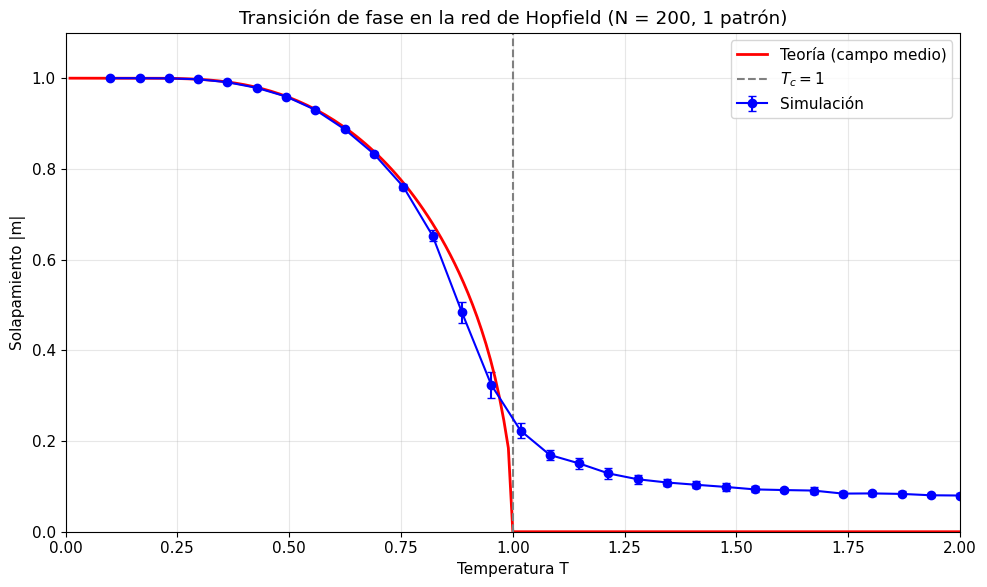


Figura 15: Curva de magnetización m(T) del modelo de Hopfield.
Modelo: N=200 neuronas, 1 patrón aleatorio, 20 realizaciones, numba + parallel.
Se observa transición de fase de segundo orden en T_c ≈ 1.


In [44]:
# Calculate curva m(T) - versión paralela
T_values = np.linspace(0.1, 2.0, 30)

n_trials = 20
n_steps = 2000
n_equilib = 1000
noise_level = 0.1

print("Calculando curva m(T) con numba + parallel...")

# Use parallelized function
m_values, m_std = hopfield_compute_m_vs_T(
    hopfield.T, 
    pattern, 
    T_values, 
    n_trials, 
    n_steps, 
    n_equilib, 
    noise_level
)

print("Cálculo completado.")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(T_values, m_values, yerr=m_std, fmt='bo-', capsize=3, 
            markersize=6, label='Simulación')

# Theoretical prediction (campo medio): m = tanh(m/T)
T_theory = np.linspace(0.01, 2.0, 200)
m_theory = []
for T in T_theory:
    if T < 1:
        m = 0.99
        for _ in range(100):
            m = np.tanh(m / T)
        m_theory.append(m)
    else:
        m_theory.append(0)

ax.plot(T_theory, m_theory, 'r-', lw=2, label='Teoría (campo medio)')
ax.axvline(1.0, color='gray', linestyle='--', label=r'$T_c = 1$')

ax.set_xlabel('Temperatura T')
ax.set_ylabel('Solapamiento |m|')
ax.set_title(f'Transición de fase en la red de Hopfield (N = {N}, 1 patrón)')
ax.legend()
ax.set_xlim(0, 2)
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

print(f"\nFigura 15: Curva de magnetización m(T) del modelo de Hopfield.")
print(f"Modelo: N={N} neuronas, 1 patrón aleatorio, {n_trials} realizaciones, numba + parallel.")
print(f"Se observa transición de fase de segundo orden en T_c ≈ 1.")

C:\Users\alisa\AppData\Local\Temp\ipykernel_6460\3113073807.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


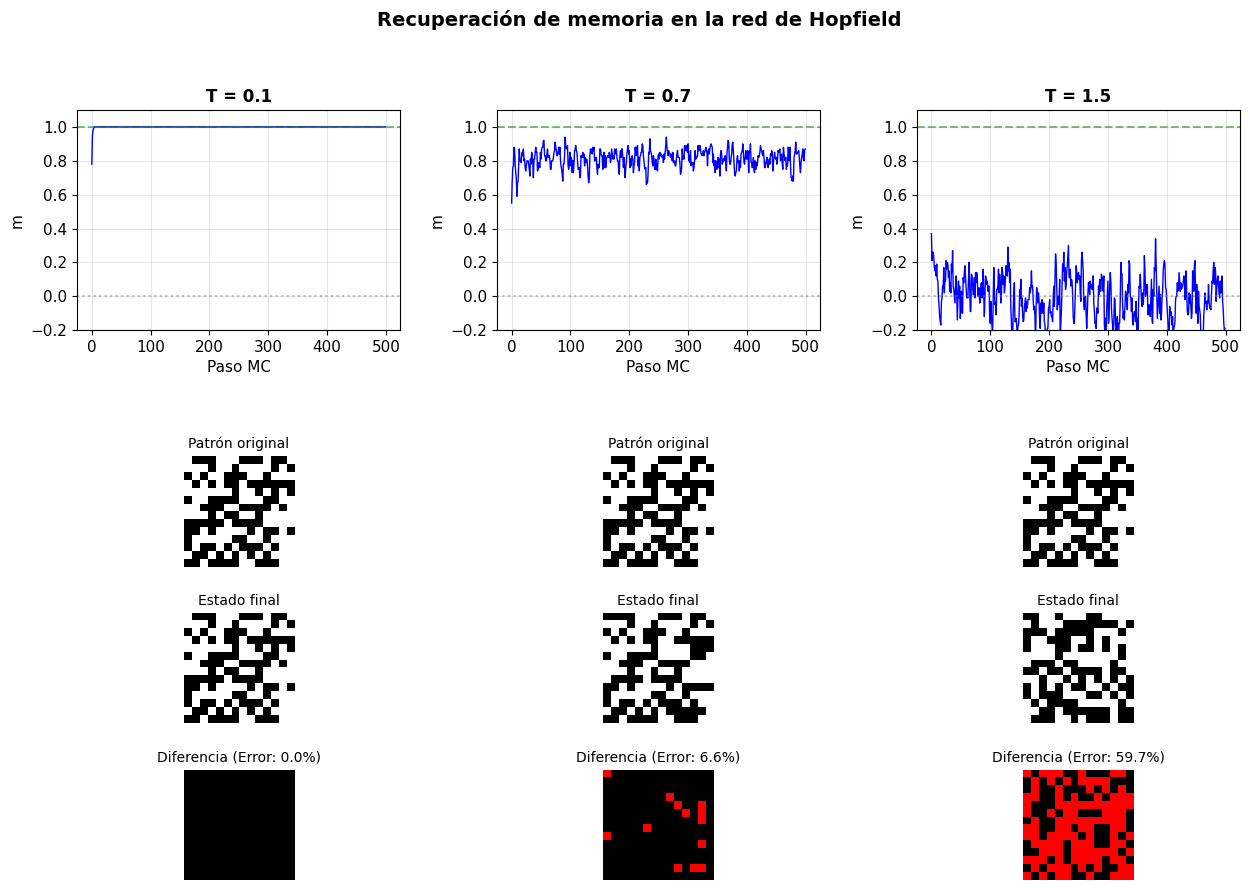


Figura 16: Dinámica de recuperación de memoria a diferentes temperaturas.
T = 0.3 (< Tc): Recuperación perfecta, m ≈ 1, error ≈ 0%.
T = 0.7 (< Tc): Recuperación con fluctuaciones, error pequeño.
T = 1.5 (> Tc): No hay recuperación, m fluctúa cerca de 0, error ≈ 50%.


In [47]:
# Visualize the dynamics de recuperación de memoria
fig = plt.figure(figsize=(15, 10))

T_examples = [0.1, 0.7, 1.5]

# Create grid: 2 filas superiores para m(t), 3 filas inferiores para imágenes
gs = fig.add_gridspec(5, 3, height_ratios=[2, 0.3, 1, 1, 1], hspace=0.4, wspace=0.3)

# Reshape patrón como imagen
side = int(np.sqrt(N))
if side * side != N:
    side = 14
    pattern_img = pattern[:side*side].reshape(side, side)
else:
    pattern_img = pattern[:side*side].reshape(side, side)

for col, T_temp in enumerate(T_examples):
    # Inicializar con versión corrupta del patrón
    np.random.seed(col + 100)  # Semilla diferente para cada T
    V0 = pattern.copy()
    flip_mask = np.random.random(N) < 0.3
    V0[flip_mask] = 1 - V0[flip_mask]
    
    # Simulate
    times, overlaps, V_final = hopfield.simulate(V0, T_temp, n_steps=500, measure_every=1)
    
    # Panel superior: evolución del solapamiento
    ax_top = fig.add_subplot(gs[0, col])
    ax_top.plot(times, overlaps, 'b-', lw=1)
    ax_top.axhline(1, color='g', linestyle='--', alpha=0.5)
    ax_top.axhline(0, color='gray', linestyle=':', alpha=0.5)
    ax_top.set_xlabel('Paso MC')
    ax_top.set_ylabel('m')
    ax_top.set_title(f'T = {T_temp}', fontsize=12, fontweight='bold')
    ax_top.set_ylim(-0.2, 1.1)
    ax_top.grid(True, alpha=0.3)
    
    # Preparar imágenes
    if side * side == N:
        final_img = V_final[:side*side].reshape(side, side)
    else:
        final_img = V_final[:side*side].reshape(side, side)
    
    diff_img = (pattern_img != final_img).astype(float)
    error = np.mean(pattern[:side*side] != V_final[:side*side])
    
    # Fila 2: Patrón original
    ax_pat = fig.add_subplot(gs[2, col])
    im1 = ax_pat.imshow(pattern_img, cmap='gray_r', vmin=0, vmax=1)
    ax_pat.set_title('Patrón original', fontsize=10)
    ax_pat.axis('off')
    
    # Fila 3: Estado final
    ax_fin = fig.add_subplot(gs[3, col])
    im2 = ax_fin.imshow(final_img, cmap='gray_r', vmin=0, vmax=1)
    ax_fin.set_title('Estado final', fontsize=10)
    ax_fin.axis('off')
    
    # Fila 4: Diferencia (errores en rojo)
    ax_diff = fig.add_subplot(gs[4, col])
    # Create imagen RGB: negro donde coinciden, rojo donde difieren
    diff_rgb = np.zeros((side, side, 3))
    diff_rgb[:, :, 0] = diff_img  # Canal rojo para errores
    im3 = ax_diff.imshow(diff_rgb)
    ax_diff.set_title(f'Diferencia (Error: {100*error:.1f}%)', fontsize=10)
    ax_diff.axis('off')

plt.suptitle('Recuperación de memoria en la red de Hopfield', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\nFigura 16: Dinámica de recuperación de memoria a diferentes temperaturas.")
print("T = 0.3 (< Tc): Recuperación perfecta, m ≈ 1, error ≈ 0%.")
print("T = 0.7 (< Tc): Recuperación con fluctuaciones, error pequeño.")
print("T = 1.5 (> Tc): No hay recuperación, m fluctúa cerca de 0, error ≈ 50%.")

### Discussion — Exercise 7

**Results:**

1. **Phase transition**: The Hopfield model exhibits a **second-order phase transition** at $T_c = 1$:
   - $T < T_c$: **Ferromagnetic** (memory) phase. Overlap $m \neq 0$: the network recalls the stored patterns.
   - $T > T_c$: **Paramagnetic** (amnesia) phase. Overlap $m = 0$: patterns are forgotten.

2. **Magnetisation curve**: Mean-field theory predicts:
   $$m = \tanh\!\left(\frac{m}{T}\right)$$
   which has a non-trivial solution ($m \neq 0$) only for $T < 1$.

3. **Associative memory**: for $T < T_c$ the network can:
   - Store patterns in its synaptic weights
   - Retrieve a pattern from a corrupted initial state (attractor dynamics)
   - The maximum storage capacity is $n_c \approx 0.14\,N$

4. **Analogy with magnetic systems**: the model is isomorphic to the **Ising model** with long-range interactions. The temperature $T$ represents **noise** in the neural system.
